---
## Main Analysis: Type A (Buried + Device) vs Type B (Buried + No Device)

**Outcomes:** (1) Flap Loss Rate, (2) Return to Theater Rate  
**Method:** DerSimonian-Laird random-effects pooled proportions (logit transform) + two-sided Wald z-test  
**Note:** Cai 2008 — all 41 fibula flaps classified as buried (monitored through intact skin).  
Reop_buried values with descriptive text (e.g., "4 (Haematoma 3 / Flap loss 1)") are parsed as leading integers.

Saved: fig2_main_forest_2x2.png / .pdf


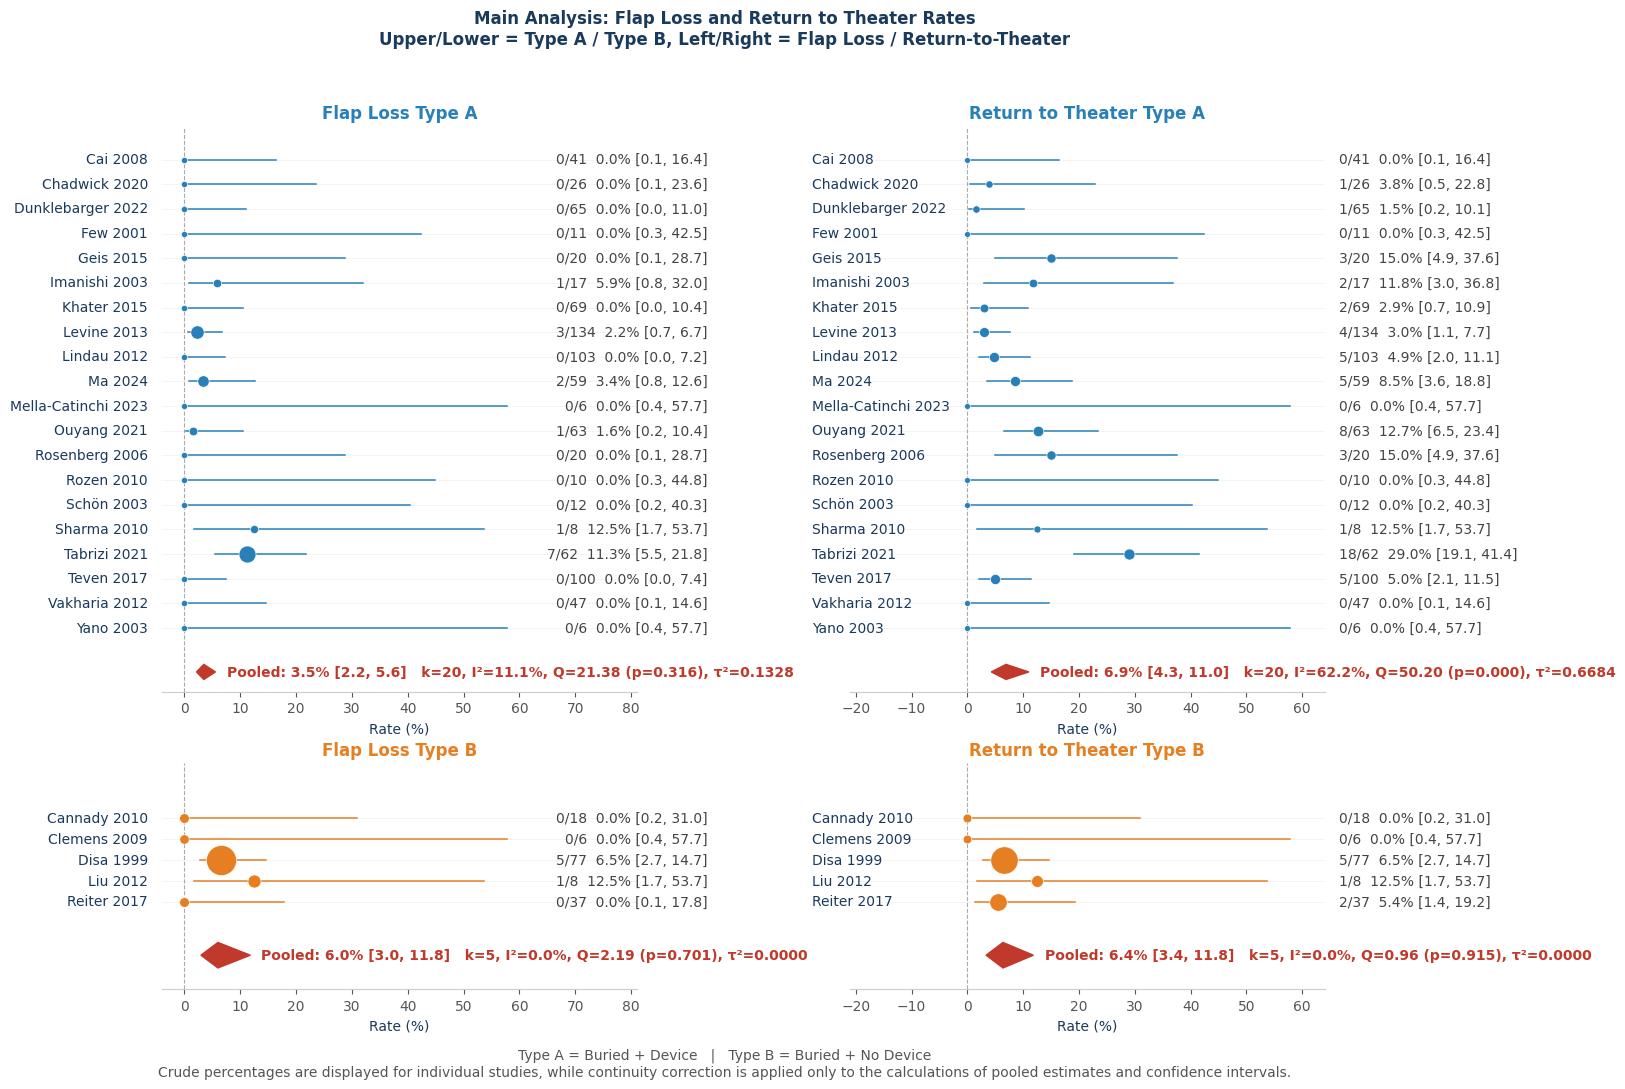

Saved: results_main_AvsB.csv


In [28]:
%matplotlib inline
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

C_HEADER  = '#1A3A5C'
C_DEVICE  = '#2980B9'
C_CONV    = '#E67E22'
C_POOL    = '#1A3A5C'
C_DIAMOND = '#C0392B'
C_GRID    = '#EEEEEE'
C_OVERALL = '#2C3E50'
C_SUBTEXT = '#666666'
DPI       = 200
LW_CI     = 1.4
LW_SP     = 0.8

df_raw = pd.read_csv('Meta_Data_C_out.csv',
                     na_values=['NA', 'NR', 'Not reported', 'Not Reported'])
df_raw.loc[df_raw['author'] == 'Cai', 'total_flap_n_buried'] = 41
df_raw['Reop_buried'] = pd.to_numeric(
    df_raw['Reop_buried'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')

dfC = df_raw[df_raw['Type'] == 'Type A'].copy().reset_index(drop=True)
dfD = df_raw[df_raw['Type'] == 'Type B'].copy().reset_index(drop=True)

def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

def inv_logit(x):
    return 1 / (1 + np.exp(-x))

def pool_prop(n_events, n_total, labels):
    n_events = np.array(n_events, dtype=float)
    n_total  = np.array(n_total,  dtype=float)
    mask0 = (n_events == 0)
    n_events_c = n_events.copy(); n_total_c = n_total.copy()
    n_events_c[mask0] += 0.5; n_total_c[mask0] += 1.0
    p_i  = n_events_c / n_total_c
    lp_i = logit(p_i)
    se_i = np.sqrt(1/n_events_c + 1/(n_total_c - n_events_c))
    p_raw = n_events / n_total
    w_fe = 1 / se_i**2
    lp_fe = np.sum(w_fe * lp_i) / np.sum(w_fe)
    Q  = np.sum(w_fe * (lp_i - lp_fe)**2)
    k  = len(lp_i)
    C  = np.sum(w_fe) - np.sum(w_fe**2) / np.sum(w_fe)
    tau2 = max(0, (Q - (k-1)) / C)
    I2   = max(0, (Q - (k-1)) / Q * 100) if Q > 0 else 0.0
    p_Q  = 1 - stats.chi2.cdf(Q, k-1)
    w_re  = 1 / (se_i**2 + tau2)
    lp_re = np.sum(w_re * lp_i) / np.sum(w_re)
    se_re = np.sqrt(1 / np.sum(w_re))
    pooled   = inv_logit(lp_re)
    ci_lo_95 = inv_logit(lp_re - 1.96 * se_re)
    ci_hi_95 = inv_logit(lp_re + 1.96 * se_re)
    wt_pct   = w_re / np.sum(w_re) * 100
    return dict(labels=labels, n_events=n_events, n_total=n_total,
                p_i=p_i, p_raw=p_raw, lp_i=lp_i, se_i=se_i, w_re=w_re, wt_pct=wt_pct,
                lp_re=lp_re, se_re=se_re, pooled=pooled,
                ci_lo_95=ci_lo_95, ci_hi_95=ci_hi_95,
                Q=Q, p_Q=p_Q, tau2=tau2, I2=I2, k=k)

def z_test(r1, r2):
    z = (r1['lp_re'] - r2['lp_re']) / np.sqrt(r1['se_re']**2 + r2['se_re']**2)
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    diff_pct = (r1['pooled'] - r2['pooled']) * 100
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '†' if p < 0.10 else 'n.s.'
    return dict(z=z, p=p, diff_pct=diff_pct, sig=sig)

def panel_xlim(*results):
    lo_vals = []
    hi_vals = []
    for r in results:
        lo_vals.extend((inv_logit(r['lp_i'] - 1.96 * r['se_i']) * 100).tolist())
        hi_vals.extend((inv_logit(r['lp_i'] + 1.96 * r['se_i']) * 100).tolist())
        lo_vals.append(r['ci_lo_95'] * 100)
        hi_vals.append(r['ci_hi_95'] * 100)
    x_min = max(-8, np.floor(min(lo_vals) - 4))
    x_max = min(125, np.ceil(max(hi_vals) + 6))
    if x_max - x_min < 35:
        mid = (x_min + x_max) / 2
        x_min = mid - 17.5
        x_max = mid + 17.5
    return float(x_min), float(x_max)

def between_device_Q(pooled_results):
    """
    Calculate between-device (between-group) heterogeneity Q statistic.
    Tests if pooled estimates differ significantly across groups.
    
    Args:
        pooled_results: List of dicts from pool_prop(), each with lp_re, se_re, pooled, etc.
    
    Returns:
        Dict with keys: Q_b (Q statistic), df_b (degrees of freedom), 
                        p_b (p-value), sig (significance marker)
    """
    if len(pooled_results) < 2:
        return dict(Q_b=0, df_b=0, p_b=1.0, sig='n.s.')
    
    # Extract logit pooled estimates and standard errors
    lp_re_values = np.array([r['lp_re'] for r in pooled_results])
    se_re_values = np.array([r['se_re'] for r in pooled_results])
    
    # Calculate weights (inverse of squared SE)
    w_re = 1 / (se_re_values ** 2)
    
    # Weighted mean of logit estimates
    lp_mean = np.sum(w_re * lp_re_values) / np.sum(w_re)
    
    # Between-device Q statistic
    Q_b = np.sum(w_re * (lp_re_values - lp_mean) ** 2)
    
    # Degrees of freedom
    df_b = len(pooled_results) - 1
    
    # P-value from chi-squared distribution
    p_b = 1 - stats.chi2.cdf(Q_b, df_b)
    
    # Significance marker
    sig = ('***' if p_b < 0.001 else '**' if p_b < 0.01 
           else '*' if p_b < 0.05 else '†' if p_b < 0.10 else 'n.s.')
    
    return dict(Q_b=Q_b, df_b=df_b, p_b=p_b, sig=sig)

def prepare_outcome(df_sub, ev_col, n_col):
    """
    Prepare outcome data for meta-regression:
    - Calculate logit-transformed rates
    - Calculate standard errors
    - Calculate random-effects weights
    
    Args:
        df_sub: DataFrame with study data
        ev_col: Name of events column
        n_col: Name of denominator column
    
    Returns:
        Tuple: (lp_i, se_i, w_re, tau2, I2)
    """
    ne = df_sub[ev_col].values.astype(float)
    nt = df_sub[n_col].values.astype(float)
    
    # Apply continuity correction for zero cells
    ne_c = ne.copy(); nt_c = nt.copy()
    mask0 = (ne == 0)
    ne_c[mask0] += 0.5
    nt_c[mask0] += 1.0
    
    # Logit transformation
    p_i = ne_c / nt_c
    lp_i = logit(p_i)
    se_i = np.sqrt(1 / ne_c + 1 / (nt_c - ne_c))
    
    # Fixed-effects meta-analysis
    w_fe = 1 / se_i**2
    lp_fe = np.sum(w_fe * lp_i) / np.sum(w_fe)
    Q = np.sum(w_fe * (lp_i - lp_fe)**2)
    k = len(lp_i)
    C = np.sum(w_fe) - np.sum(w_fe**2) / np.sum(w_fe)
    tau2 = max(0.0, (Q - (k - 1)) / C)
    I2 = max(0.0, (Q - (k - 1)) / Q * 100) if Q > 0 else 0.0
    
    # Random-effects weights
    w_re = 1 / (se_i**2 + tau2)
    
    return lp_i, se_i, w_re, tau2, I2

def wls_metareg(y, X, w):
    """
    Weighted least squares meta-regression.
    
    Args:
        y: Outcome (logit estimates)
        X: Design matrix (column of 1s + covariates)
        w: Weights (random-effects weights)
    
    Returns:
        Tuple: (beta, se_b, t_stats, p_values, R2)
    """
    # Weighted regression
    W = np.diag(w)
    XtWX = X.T @ W @ X
    XtWy = X.T @ W @ y
    
    # Estimate beta
    beta = np.linalg.solve(XtWX, XtWy)
    
    # Residuals and residual standard error
    yhat = X @ beta
    resid = y - yhat
    ss_resid = np.sum(w * resid**2)
    df_resid = len(y) - X.shape[1]
    rse = np.sqrt(ss_resid / df_resid)
    
    # Standard errors
    var_cov = rse**2 * np.linalg.inv(XtWX)
    se_b = np.sqrt(np.diag(var_cov))
    
    # t-statistics and p-values
    t_stats = beta / se_b
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df_resid))
    
    # R-squared
    ss_tot = np.sum(w * (y - np.sum(w * y) / np.sum(w))**2)
    R2 = 1 - (ss_resid / ss_tot) if ss_tot > 0 else 0
    
    return beta, se_b, t_stats, p_values, R2

def draw_panel(ax, r, title, color, x_min, x_max, panel_col=None, row_index=None):
    k = r['k']
    step = 0.72 if row_index == 0 or row_index is None else 0.36
    y_pos = np.arange(k, 0, -1) * step
    
    # Calculate padding for text clearance
    x_range = x_max - x_min
    text_margin = 0.25 * x_range  # 12% padding on each side
    
    # Adjust xlim based on panel position to provide space for text
    if panel_col == 0:  # Left column: add space on right for numerical data
        x_min_plot = x_min
        x_max_plot = x_max + text_margin
    elif panel_col == 1:  # Right column: add space on left for author/year
        x_min_plot = x_min - text_margin
        x_max_plot = x_max
    else:
        x_min_plot = x_min
        x_max_plot = x_max
    
    # Set plot data limits with padding
    ax.set_xlim(x_min_plot, x_max_plot)
    ax.set_ylim(-1.15, y_pos[0] + 0.95)
    
    for yy in y_pos:
        ax.axhline(yy, color=C_GRID, lw=0.45, zorder=0)
    ax.axvline(0, color='#AAAAAA', lw=0.8, ls='--', zorder=1)

    # Normalize y_pos to axes coordinates (0-1)
    y_data_min = -1.15
    y_data_max = y_pos[0] + 0.95
    
    # Adjust text positions based on panel column (0=left, 1=right)
    left_text_x = -0.03
    right_text_x = 1.03
    
    if panel_col == 0:  # Left column: bring right text inward
        right_text_x = 1.15
    elif panel_col == 1:  # Right column: bring left text inward
        left_text_x = -0.08
    
    for i, (y, lbl, lp, se, ne, nt, wt) in enumerate(zip(
            y_pos, r['labels'], r['lp_i'], r['se_i'], r['n_events'], r['n_total'], r['wt_pct'])):
        lo = inv_logit(lp - 1.96 * se) * 100
        hi = inv_logit(lp + 1.96 * se) * 100
        pc = r['p_raw'][i] * 100
        ax.plot([lo, hi], [y, y], color=color, lw=1.1, zorder=2)
        ax.scatter(pc, y, s=max(18, wt * 7), color=color,
                   zorder=3, edgecolors='white', linewidths=0.45)
        
        # Normalize y to axes coordinates (0-1 scale)
        norm_y = (y - y_data_min) / (y_data_max - y_data_min)
        
        # Position author/year labels on left using FULL axes coordinates
        ax.text(left_text_x, norm_y, lbl, ha='right' if panel_col != 1 else 'left', 
                va='center', fontsize=10, color=C_HEADER, transform=ax.transAxes, clip_on=False)
        
        # Position numerical data on right using FULL axes coordinates
        ax.text(right_text_x, norm_y, f'{int(ne)}/{int(nt)}  {pc:.1f}% [{lo:.1f}, {hi:.1f}]',
                ha='left' if panel_col != 0 else 'right', va='center', fontsize=10, 
                color='#444444', transform=ax.transAxes, clip_on=False)

    cx = r['pooled'] * 100
    lo95 = r['ci_lo_95'] * 100
    hi95 = r['ci_hi_95'] * 100
    y_d = -0.56
    dh = 0.22
    ax.add_patch(plt.Polygon(
        [[lo95, y_d], [cx, y_d + dh], [hi95, y_d], [cx, y_d - dh]],
        closed=True, color=C_DIAMOND, zorder=4))
    ax.text(hi95 + 2, y_d,
            f'Pooled: {cx:.1f}% [{lo95:.1f}, {hi95:.1f}]   '
            f'k={r["k"]}, I²={r["I2"]:.1f}%, Q={r["Q"]:.2f} (p={r["p_Q"]:.3f}), τ²={r["tau2"]:.4f}',
            ha='left', va='center', fontsize=10, fontweight='bold', color=C_DIAMOND)

    ax.set_title(title, fontsize=12, fontweight='bold', color=color, pad=6)
    ax.set_yticks([])
    ax.set_xlabel('Rate (%)', fontsize=10, color=C_HEADER)
    ax.tick_params(axis='x', colors='#555555', labelsize=10)
    for sp in ['top', 'right', 'left']:
        ax.spines[sp].set_visible(False)
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.spines['bottom'].set_linewidth(0.8)

# --- Flap Loss ---
cFL = dfC.dropna(subset=['total_flap_n_buried','flap_loss_buried']).copy()
dFL = dfD.dropna(subset=['total_flap_n_buried','flap_loss_buried']).copy()
rC_FL = pool_prop(cFL['flap_loss_buried'].values, cFL['total_flap_n_buried'].values,
                  (cFL['author']+' '+cFL['year'].astype(str)).tolist())
rD_FL = pool_prop(dFL['flap_loss_buried'].values, dFL['total_flap_n_buried'].values,
                  (dFL['author']+' '+dFL['year'].astype(str)).tolist())
cmp_FL = z_test(rC_FL, rD_FL)

# --- Return to Theater ---
cRT = dfC.dropna(subset=['total_flap_n_buried','Reop_buried']).copy()
dRT = dfD.dropna(subset=['total_flap_n_buried','Reop_buried']).copy()
rC_RT = pool_prop(cRT['Reop_buried'].values, cRT['total_flap_n_buried'].values,
                  (cRT['author']+' '+cRT['year'].astype(str)).tolist())
rD_RT = pool_prop(dRT['Reop_buried'].values, dRT['total_flap_n_buried'].values,
                  (dRT['author']+' '+dRT['year'].astype(str)).tolist())
cmp_RT = z_test(rC_RT, rD_RT)

# --- Combined 2x2 layout ---
fig, axes = plt.subplots(2, 2, figsize=(15, 11.2), facecolor='white', gridspec_kw={'height_ratios': [1.0, 0.4]})
plt.subplots_adjust(wspace=0.45, hspace=0.18)

xlim_flap = panel_xlim(rC_FL, rD_FL)
xlim_reop = panel_xlim(rC_RT, rD_RT)

# Left column (flaploss): panel_col=0
draw_panel(axes[0, 0], rC_FL, 'Flap Loss Type A', C_DEVICE, *xlim_flap, panel_col=0, row_index=0)
draw_panel(axes[1, 0], rD_FL, 'Flap Loss Type B', C_CONV, *xlim_flap, panel_col=0, row_index=1)

# Right column (return-to-theater): panel_col=1
draw_panel(axes[0, 1], rC_RT, 'Return to Theater Type A', C_DEVICE, *xlim_reop, panel_col=1, row_index=0)
draw_panel(axes[1, 1], rD_RT, 'Return to Theater Type B', C_CONV, *xlim_reop, panel_col=1, row_index=1)

fig.suptitle(
    'Main Analysis: Flap Loss and Return to Theater Rates\n'
    'Upper/Lower = Type A / Type B, Left/Right = Flap Loss / Return-to-Theater',
    fontsize=12, fontweight='bold', color=C_HEADER, y=0.985)

fig.text(0.5, 0.03,
         'Type A = Buried + Device   |   Type B = Buried + No Device\n'
         'Crude percentages are displayed for individual studies, while continuity correction is applied only to the calculations of pooled estimates and confidence intervals.',
         ha='center', va='bottom', fontsize=10, color='#555555')

plt.savefig('fig2_main_forest_2x2.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.savefig('fig2_main_forest_2x2.pdf', bbox_inches='tight', facecolor='white')
print('Saved: fig2_main_forest_2x2.png / .pdf')
plt.show()

# --- Export CSV ---
rows = []
for outcome, rC, rD, cmp in [
        ('Flap Loss Rate', rC_FL, rD_FL, cmp_FL),
        ('Return to Theater Rate', rC_RT, rD_RT, cmp_RT)]:
    for grp, r in [('Type A (Buried+Device)', rC), ('Type B (Buried+No Device)', rD)]:
        rows.append(dict(
            Outcome=outcome, Group=grp, k=r['k'],
            Pooled_pct=round(r['pooled']*100,2),
            CI95_Lo=round(r['ci_lo_95']*100,2),
            CI95_Hi=round(r['ci_hi_95']*100,2),
            I2_pct=round(r['I2'],1), Q=round(r['Q'],3),
            p_Q=round(r['p_Q'],4), tau2=round(r['tau2'],4),
            Diff_CminusD_pct=round(cmp['diff_pct'],2),
            z=round(cmp['z'],3), p_value=round(cmp['p'],4), Sig=cmp['sig']))
pd.DataFrame(rows).to_csv('results_main_AvsB.csv', index=False)
print('Saved: results_main_AvsB.csv')

### Results Summary

| Outcome | Type A (k=20) | Type B (k=5) | Difference (C−D) | z | p |
|---|---|---|---|---|---|
| Flap Loss Rate | 3.5% [2.2, 5.6] | 6.0% [3.0, 11.8] | −2.52% | −1.26 | 0.207 n.s. |
| Return to Theater Rate | 6.9% [4.3, 11.0] | 6.4% [3.4, 11.8] | +0.55% | 0.20 | 0.839 n.s. |

**Note:** Type A I² for Return to Theater = 62.2% (substantial heterogeneity).  
Type B I² = 0% for both outcomes (k=5, low power).


=== Type A site classification ===
        author  year  total_flap_n_buried  recon_area_hn  recon_area_breast  recon_area_other  site_group  flap_loss_buried
           Cai  2008                   41           41.0                0.0               0.0 Head & Neck               0.0
      Chadwick  2020                   26            0.0               26.0               0.0      Breast               0.0
  Dunklebarger  2022                   65           65.0                0.0               0.0 Head & Neck               0.0
           Few  2001                   11           11.0                0.0               0.0 Head & Neck               0.0
          Geis  2015                   20            NaN                5.0               NaN Other/Mixed               0.0
      Imanishi  2003                   17           17.0                0.0               0.0 Head & Neck               1.0
        Khater  2015                   69            0.0                0.0              69.0 Oth

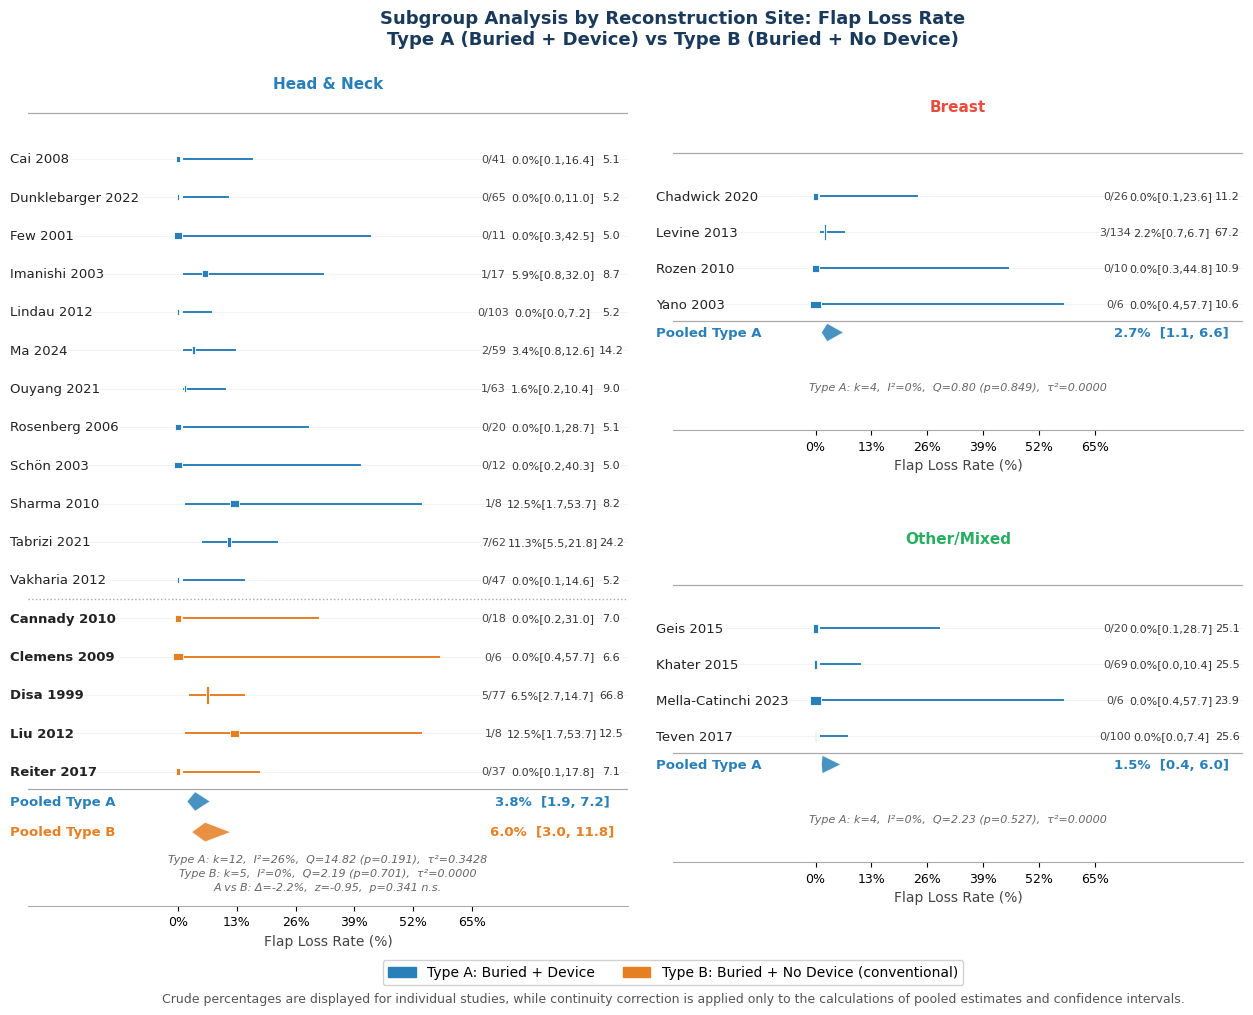


=== Subgroup results by reconstruction site ===
       Site  Group  k  Pooled_pct  CI95_Lo  CI95_Hi  I2_pct      Q    p_Q   tau2      z  p_value  Sig Note
Head & Neck Type A 12        3.76     1.93     7.19    25.8 14.816 0.1911 0.3428 -0.953   0.3408 n.s.     
Head & Neck Type B  5        6.00     2.95    11.80     0.0  2.187 0.7014 0.0000 -0.953   0.3408 n.s.     
     Breast Type A  4        2.69     1.07     6.59     0.0  0.803 0.8488 0.0000    NaN      NaN  NaN     
Other/Mixed Type A  4        1.54     0.38     5.99     0.0  2.227 0.5267 0.0000    NaN      NaN  NaN     

Saved: results_subgroup_site.csv


In [29]:
"""
Analysis Step #2: Subgroup Analysis by Reconstruction Site
  - Groups: Head & Neck / Breast / Other/Mixed
  - Outcome: Flap Loss Rate
  - Comparison: Type A (Buried + Device) vs Type B (Buried + No Device)
  - Method: DerSimonian-Laird random-effects, logit transformation
  - Between-group z-test within each site subgroup
  - Layout: 1×4 vertical, legacy style (no color fill, large text)
"""

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── フォント設定 ───────────────────────────────────────────────────────────
def _set_font():
    import matplotlib.font_manager as fm
    preferred = ['DejaVu Sans', 'Arial', 'Helvetica', 'sans-serif']
    available = {f.name for f in fm.fontManager.ttflist}
    for font in preferred:
        if font in available:
            matplotlib.rcParams['font.family'] = font
            break
    else:
        matplotlib.rcParams['font.family'] = 'sans-serif'
    matplotlib.rcParams['font.sans-serif'] = preferred

_set_font()

# ── カラー定数 ─────────────────────────────────────────────────────────────
C_HEADER  = '#1A3A5C'
C_DEVICE  = '#2980B9'   # Type A
C_CONV    = '#E67E22'   # Type B
C_DIAMOND = '#C0392B'
C_GRID    = '#EEEEEE'
C_SUBTEXT = '#666666'
DPI       = 200
LW_CI     = 1.4
LW_SP     = 0.8

# ── 1. データ読み込み ──────────────────────────────────────────────────────
df = pd.read_csv('Meta_Data_C_out.csv',
                 na_values=['NA', 'NR', 'Not reported', 'Not Reported'])
df['Reop_buried'] = pd.to_numeric(
    df['Reop_buried'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')

# ── 2. 施設分類 ────────────────────────────────────────────────────────────
def classify_site(row):
    n = row['total_flap_n_buried']
    if pd.isna(n) or n == 0:
        return 'Unknown'
    hn = row['recon_area_hn']     if not pd.isna(row['recon_area_hn'])     else 0
    br = row['recon_area_breast'] if not pd.isna(row['recon_area_breast']) else 0
    ot = row['recon_area_other']  if not pd.isna(row['recon_area_other'])  else 0
    if hn / n >= 0.5:
        return 'Head & Neck'
    elif br / n >= 0.5:
        return 'Breast'
    else:
        return 'Other/Mixed'

df['site_group'] = df.apply(classify_site, axis=1)

dfA = df[df['Type'] == 'Type A'].copy().reset_index(drop=True)
dfB = df[df['Type'] == 'Type B'].copy().reset_index(drop=True)

print("=== Type A site classification ===")
print(dfA[['author', 'year', 'total_flap_n_buried',
           'recon_area_hn', 'recon_area_breast', 'recon_area_other',
           'site_group', 'flap_loss_buried']].to_string(index=False))
print()
print("=== Type B site classification ===")
print(dfB[['author', 'year', 'total_flap_n_buried',
           'recon_area_hn', 'recon_area_breast', 'recon_area_other',
           'site_group', 'flap_loss_buried']].to_string(index=False))

# ── 3. 統計関数 ────────────────────────────────────────────────────────────
def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

def inv_logit(x):
    return 1 / (1 + np.exp(-x))

def pool_prop(n_events, n_total, labels):
    n_events = np.array(n_events, dtype=float)
    n_total  = np.array(n_total,  dtype=float)
    mask0 = (n_events == 0)
    ne = n_events.copy(); nt = n_total.copy()
    ne[mask0] += 0.5;    nt[mask0] += 1.0
    p_i  = ne / nt
    p_raw = n_events / n_total
    lp_i = logit(p_i)
    se_i = np.sqrt(1/ne + 1/(nt - ne))
    w_fe  = 1 / se_i**2
    lp_fe = np.sum(w_fe * lp_i) / np.sum(w_fe)
    Q  = np.sum(w_fe * (lp_i - lp_fe)**2)
    k  = len(lp_i)
    C  = np.sum(w_fe) - np.sum(w_fe**2) / np.sum(w_fe)
    tau2 = max(0.0, (Q - (k - 1)) / C)
    I2   = max(0.0, (Q - (k - 1)) / Q * 100) if Q > 0 else 0.0
    p_Q  = 1 - stats.chi2.cdf(Q, k - 1)
    w_re  = 1 / (se_i**2 + tau2)
    lp_re = np.sum(w_re * lp_i) / np.sum(w_re)
    se_re = np.sqrt(1 / np.sum(w_re))
    pooled   = inv_logit(lp_re)
    ci_lo_95 = inv_logit(lp_re - 1.96 * se_re)
    ci_hi_95 = inv_logit(lp_re + 1.96 * se_re)
    wt_pct   = w_re / np.sum(w_re) * 100
    return dict(
        labels=labels, k=k,
        n_events=n_events, n_total=n_total,
        p_i=p_i, p_raw=p_raw, lp_i=lp_i, se_i=se_i, wt_pct=wt_pct,
        lp_re=lp_re, se_re=se_re,
        pooled=pooled, ci_lo_95=ci_lo_95, ci_hi_95=ci_hi_95,
        Q=Q, p_Q=p_Q, tau2=tau2, I2=I2)

def z_test_between(r1, r2):
    z   = (r1['lp_re'] - r2['lp_re']) / np.sqrt(r1['se_re']**2 + r2['se_re']**2)
    p   = 2 * (1 - stats.norm.cdf(abs(z)))
    sig = ('***' if p < 0.001 else '**' if p < 0.01
           else '*' if p < 0.05 else '†' if p < 0.10 else 'n.s.')
    return dict(z=z, p=p, sig=sig,
                diff_pct=(r1['pooled'] - r2['pooled']) * 100)

# ── 4. x軸範囲の自動決定 ──────────────────────────────────────────────────
def _pick_rate_xlim_from_entries(entries):
    lo_list, hi_list = [], []
    for typ, lbl, ne, nt in entries:
        ne_c = ne + 0.5 if ne == 0 else ne
        nt_c = nt + 1.0 if ne == 0 else nt
        lp = logit(ne_c / nt_c)
        se = np.sqrt(1/ne_c + 1/(nt_c - ne_c))
        lo_list.append(inv_logit(lp - 1.96*se) * 100)
        hi_list.append(inv_logit(lp + 1.96*se) * 100)
    raw_min = max(0.0,   min(lo_list))
    raw_max = min(100.0, max(hi_list))
    margin  = max(1.0, (raw_max - raw_min) * 0.15)
    x_min   = max(0.0,   raw_min - margin)
    x_max   = min(100.0, raw_max + margin)
    if x_max - x_min < 5.0:
        mid   = (x_min + x_max) / 2
        x_min = max(0.0,   mid - 2.5)
        x_max = min(100.0, mid + 2.5)
    return x_min, x_max

# ── 5. 1パネル描画関数 ─────────────────────────────────────────────────────
def _draw_panel(ax, entries, pool_res, cmp, site, color):
    k_total = len(entries)
    k_A     = sum(1 for t, *_ in entries if t == 'A')
    y_pos   = np.arange(k_total, 0, -1, dtype=float)

    x_min, x_max = _pick_rate_xlim_from_entries(entries)
    data_w = x_max - x_min

    # 25% padding on both sides to avoid overlap with text columns
    x_pad = data_w * 0.50
    x_plot_min = x_min - x_pad
    x_plot_max = x_max + x_pad

    pad_l = data_w * 0.02
    pad_r = data_w * 0.02

    T = ax.get_yaxis_transform()

    cx_study = -0.03
    # 右側テキスト列を1/3に圧縮して中央寄せ
    base = 0.72      # 左端（少し中央寄りに）
    width = 0.28     # 元 ~0.36 → 約1/3

    cx_ev   = base + width * 0.20
    cx_rate = base + width * 0.55
    cx_wt   = base + width * 0.90

    # Header text removed, but separator line kept
    ax.axhline(k_total + 1.2, color='#AAAAAA', lw=0.9)

    for yy in y_pos:
        ax.axhline(yy, color=C_GRID, lw=0.5, zorder=0)

    for i, (typ, lbl, ne, nt) in enumerate(entries):
        y    = y_pos[i]
        ne_c = ne + 0.5 if ne == 0 else ne
        nt_c = nt + 1.0 if ne == 0 else nt

        lp = logit(ne_c / nt_c)
        se = np.sqrt(1/ne_c + 1/(nt_c - ne_c))

        lo = inv_logit(lp - 1.96 * se) * 100
        hi = inv_logit(lp + 1.96 * se) * 100
        pc = (ne / nt) * 100

        wt = pool_res[typ]['wt_pct'][
            list(pool_res[typ]['labels']).index(lbl)
        ] if typ in pool_res and lbl in pool_res[typ]['labels'] else 10.0

        c_pt = C_DEVICE if typ == 'A' else C_CONV

        ax.plot(
            [max(lo, x_min + pad_l), min(hi, x_max - pad_r)],
            [y, y],
            color=c_pt, lw=LW_CI, zorder=2
        )

        sq_h = 0.14 + wt / 100 * 0.46
        sq_w = max(0.3, (hi - lo) * 0.04 + wt / 100 * 0.5)

        ax.add_patch(mpatches.Rectangle(
            (pc - sq_w / 2, y - sq_h / 2),
            sq_w, sq_h,
            facecolor=c_pt,
            edgecolor='white',
            lw=0.6,
            zorder=3
        ))

        ax.text(
            cx_study, y, lbl,
            transform=T,
            fontsize=9.5,
            color='#222222',
            ha='left',
            va='center',
            fontweight='bold' if typ == 'B' else 'normal'
        )

        ax.text(
            cx_ev, y,
            f'{int(ne)}/{int(nt)}',
            transform=T,
            fontsize=8,
            color='#444444',
            ha='center',
            va='center'
        )

        ax.text(
            cx_rate, y,
            f'{pc:.1f}%[{lo:.1f},{hi:.1f}]',
            transform=T,
            fontsize=8,
            color='#333333',
            ha='center',
            va='center'
        )

        ax.text(
            cx_wt, y,
            f'{wt:.1f}',
            transform=T,
            fontsize=8,
            color='#333333',
            ha='center',
            va='center'
        )

    # Type A / B separator only; "▼ Type B" text removed
    if 0 < k_A < k_total:
        sep_y = y_pos[k_A - 1] - 0.5
        ax.axhline(sep_y, color='#AAAAAA', lw=1.0, ls=':', zorder=3)

    ax.axhline(0.55, color='#AAAAAA', lw=0.9)

    for typ, y_d in [('A', 0.22), ('B', -0.58)]:
        if typ not in pool_res:
            continue

        r = pool_res[typ]

        cx   = r['pooled'] * 100
        lo95 = r['ci_lo_95'] * 100
        hi95 = r['ci_hi_95'] * 100
        dh   = 0.26
        c_d  = C_DEVICE if typ == 'A' else C_CONV

        ax.add_patch(mpatches.Polygon(
            [
                [max(lo95, x_min + pad_l), y_d],
                [cx, y_d + dh],
                [min(hi95, x_max - pad_r), y_d],
                [cx, y_d - dh]
            ],
            closed=True,
            facecolor=c_d,
            edgecolor='white',
            lw=0.8,
            zorder=4,
            alpha=0.85
        ))

        lbl_t = 'A' if typ == 'A' else 'B'

        ax.text(
            cx_study, y_d,
            f'Pooled Type {lbl_t}',
            transform=T,
            fontsize=9.5,
            fontweight='bold',
            color=c_d,
            ha='left',
            va='center'
        )

        ax.text(
            cx_rate, y_d,
            f'{cx:.1f}%  [{lo95:.1f}, {hi95:.1f}]',
            transform=T,
            fontsize=9.5,
            fontweight='bold',
            color=c_d,
            ha='center',
            va='center'
        )

    het_lines = []

    for typ in ['A', 'B']:
        if typ not in pool_res:
            continue

        r = pool_res[typ]
        lbl_t = 'A' if typ == 'A' else 'B'

        het_lines.append(
            f'Type {lbl_t}: k={r["k"]},  I²={r["I2"]:.0f}%,  '
            f'Q={r["Q"]:.2f} (p={r["p_Q"]:.3f}),  τ²={r["tau2"]:.4f}'
        )

    if cmp is not None:
        het_lines.append(
            f'A vs B: Δ={cmp["diff_pct"]:+.1f}%,  '
            f'z={cmp["z"]:.2f},  p={cmp["p"]:.3f} {cmp["sig"]}'
        )

    ax.text(
        0.5, -1.15,
        '\n'.join(het_lines),
        transform=T,
        fontsize=8.0,
        color=C_SUBTEXT,
        ha='center',
        va='top',
        style='italic',
        linespacing=1.5
    )

    ax.set_xlim(x_plot_min, x_plot_max)
    ax.set_ylim(-2.5, k_total + 2.5)

    tick_step = max(1, round(data_w / 5))
    x_ticks = np.arange(
        np.ceil(x_min / tick_step) * tick_step,
        x_max + 0.001,
        tick_step
    )
    x_ticks = x_ticks[(x_ticks >= x_min) & (x_ticks <= x_max)]

    ax.set_xticks(x_ticks)
    ax.set_xticklabels([f'{v:.0f}%' for v in x_ticks], fontsize=9)

    ax.set_xlabel('Flap Loss Rate (%)', fontsize=10, color='#444444')
    ax.set_yticks([])

    for sp in ax.spines.values():
        sp.set_visible(False)

    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color('#AAAAAA')
    ax.spines['bottom'].set_linewidth(LW_SP)

    ax.set_title(site, fontsize=11, fontweight='bold', color=color, y=0.96)

# ── 6. 全サイトのデータ収集と描画 ─────────────────────────────────────────
sites       = ['Head & Neck', 'Breast', 'Other/Mixed']
site_colors = {
    'Head & Neck': '#2980B9',
    'Breast':      '#E74C3C',
    'Other/Mixed': '#27AE60',
}

# パネルごとの行数を先に計算してfigure高さを決める
panel_data = []   # (entries, pool_res, cmp, site)
results_out = []

for site in sites:
    sA = dfA[(dfA['site_group'] == site) &
             dfA['total_flap_n_buried'].notna() &
             dfA['flap_loss_buried'].notna()].copy()
    sB = dfB[(dfB['site_group'] == site) &
             dfB['total_flap_n_buried'].notna() &
             dfB['flap_loss_buried'].notna()].copy()

    entries = []
    for _, row in sA.iterrows():
        entries.append(('A', f"{row['author']} {row['year']}",
                        float(row['flap_loss_buried']),
                        float(row['total_flap_n_buried'])))
    for _, row in sB.iterrows():
        entries.append(('B', f"{row['author']} {row['year']}",
                        float(row['flap_loss_buried']),
                        float(row['total_flap_n_buried'])))

    pool_res = {}
    for typ, sub in [('A', sA), ('B', sB)]:
        sub2 = sub.dropna(subset=['total_flap_n_buried', 'flap_loss_buried'])
        if len(sub2) >= 2:
            r = pool_prop(sub2['flap_loss_buried'].values,
                          sub2['total_flap_n_buried'].values,
                          (sub2['author'] + ' ' + sub2['year'].astype(str)).tolist())
            pool_res[typ] = r
            results_out.append(dict(
                Site=site, Group=f'Type {typ}', k=r['k'],
                Pooled_pct=round(r['pooled']*100, 2),
                CI95_Lo=round(r['ci_lo_95']*100, 2),
                CI95_Hi=round(r['ci_hi_95']*100, 2),
                I2_pct=round(r['I2'], 1), Q=round(r['Q'], 3),
                p_Q=round(r['p_Q'], 4), tau2=round(r['tau2'], 4),
                z=None, p_value=None, Sig=None, Note=''))
        elif len(sub2) == 1:
            r_s = sub2.iloc[0]
            results_out.append(dict(
                Site=site, Group=f'Type {typ}', k=1,
                Pooled_pct=round(
                    r_s['flap_loss_buried']/r_s['total_flap_n_buried']*100, 2),
                CI95_Lo=None, CI95_Hi=None,
                I2_pct=None, Q=None, p_Q=None, tau2=None,
                z=None, p_value=None, Sig=None,
                Note='Single study, not pooled'))

    cmp = None
    if 'A' in pool_res and 'B' in pool_res:
        cmp = z_test_between(pool_res['A'], pool_res['B'])
        for row in results_out[-2:]:
            row['z']       = round(cmp['z'], 3)
            row['p_value'] = round(cmp['p'], 4)
            row['Sig']     = cmp['sig']

    panel_data.append((entries, pool_res, cmp, site))

# ── 7. figure生成（2列レイアウト）────────────────────────────────────────
fig = plt.figure(figsize=(15, 10.8), facecolor='white')

# 2列構成: Head & Neck を左、Breast / Other-Mixed を右上下に配置
# 目安の高さ比: 左 0.8、右上 0.3、右下 0.3
panel_pos = {
    'Head & Neck': [0.07, 0.12, 0.40, 0.78],
    'Breast':      [0.50, 0.56, 0.38, 0.30],
    'Other/Mixed': [0.50, 0.16, 0.38, 0.30],
}

for entries, pool_res, cmp, site in panel_data:
    ax = fig.add_axes(panel_pos[site])
    color = site_colors[site]
    if len(entries) == 0:
        ax.text(0.5, 0.5, f'No data for {site}',
                ha='center', va='center', transform=ax.transAxes, fontsize=11)
        ax.set_title(site, fontsize=11, fontweight='bold', color=color)
        ax.axis('off')
        continue
    _draw_panel(ax, entries, pool_res, cmp, site, color)

# ── 8. 凡例・タイトル ─────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color=C_DEVICE, label='Type A: Buried + Device'),
    mpatches.Patch(color=C_CONV,   label='Type B: Buried + No Device (conventional)'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=2,
           fontsize=10, framealpha=0.9, bbox_to_anchor=(0.5, 0.04))

fig.suptitle(
    'Subgroup Analysis by Reconstruction Site: Flap Loss Rate\n'
    'Type A (Buried + Device) vs Type B (Buried + No Device)',
    fontsize=13, fontweight='bold', color=C_HEADER, y=0.95)

fig.text(0.5, 0.04,
         'Crude percentages are displayed for individual studies, while continuity correction is applied only to the calculations of pooled estimates and confidence intervals.',
         ha='center', va='top', fontsize=9, color='#555555')

plt.savefig('fig3_subgroup_site.png', dpi=600,
            bbox_inches='tight', facecolor='white')
plt.savefig('fig3_subgroup_site.pdf',
            bbox_inches='tight', facecolor='white')
print('\nSaved: fig3_subgroup_site.png / .pdf')
plt.show()

# ── 9. 結果表示・CSV出力 ──────────────────────────────────────────────────
df_out = pd.DataFrame(results_out)
print()
print("=== Subgroup results by reconstruction site ===")
print(df_out.to_string(index=False))

df_out.to_csv('results_subgroup_site.csv', index=False)
print('\nSaved: results_subgroup_site.csv')

Saved: fig4_subgroup_device_combined_1x2.png / .pdf


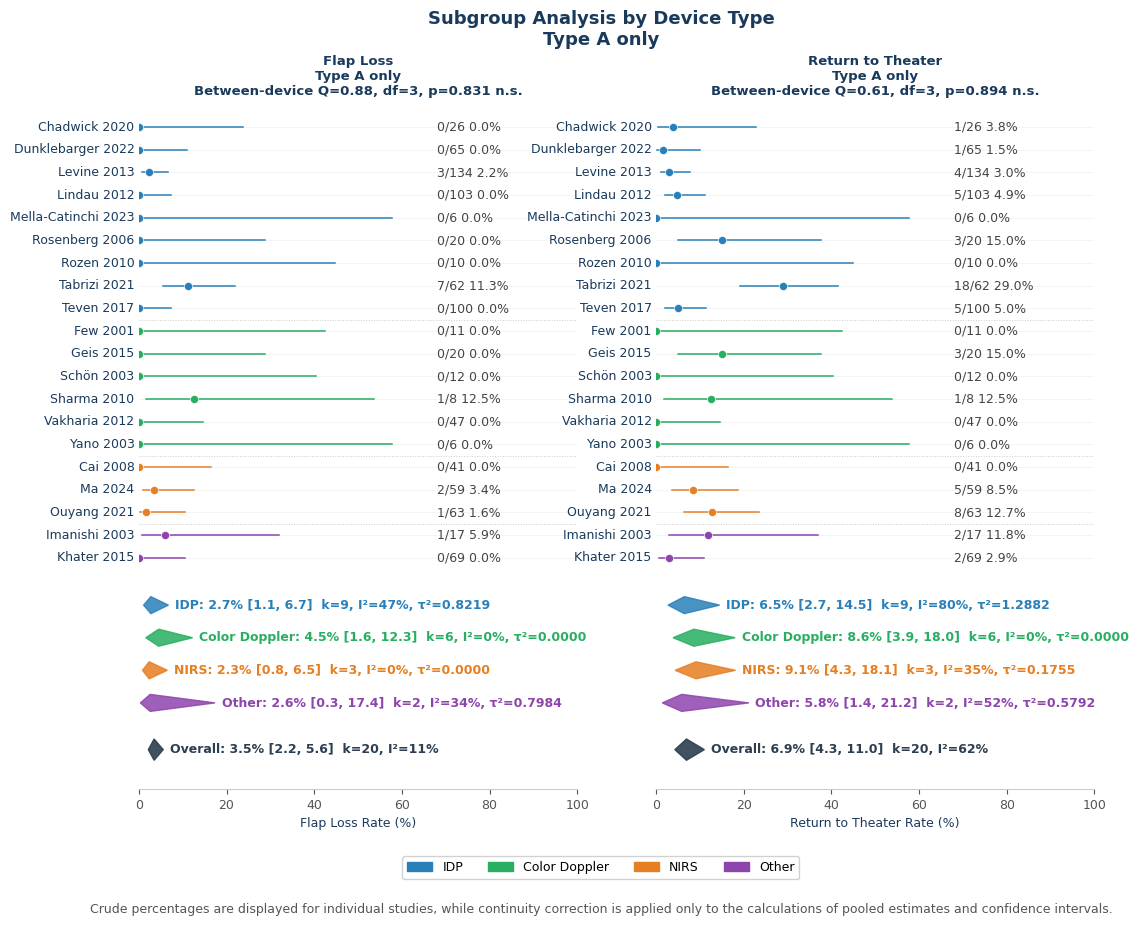


=== Device subgroup results ===
          Outcome           Device  k  Pooled_pct  CI95_Lo  CI95_Hi  I2_pct      Q    p_Q   tau2    Note
        Flap Loss              IDP  9        2.73     1.08     6.73    47.1 15.122 0.0568 0.8219        
        Flap Loss    Color Doppler  6        4.52     1.58    12.26     0.0  2.527 0.7724 0.0000        
        Flap Loss             NIRS  3        2.35     0.82     6.49     0.0  0.669 0.7158 0.0000        
        Flap Loss            Other  2        2.57     0.33    17.38    34.2  1.519 0.2178 0.7984        
        Flap Loss Between-device Q  4         NaN      NaN      NaN     NaN  0.877 0.8310    NaN    n.s.
        Flap Loss   Overall Type A 20        3.48     2.16     5.56    11.1 21.382 0.3161 0.1328 Overall
Return to Theater              IDP  9        6.45     2.73    14.49    79.6 39.237 0.0000 1.2882        
Return to Theater    Color Doppler  6        8.62     3.88    18.04     0.0  4.191 0.5222 0.0000        
Return to Theater     

In [34]:
# ── 3. Build forest plot ───────────────────────────────────────────────────────
DEVICE_COLORS = {
    'IDP':           '#2980B9',
    'Color Doppler': '#27AE60',
    'NIRS':          '#E67E22',
    'Other':         '#8E44AD',
}

DEVICE_ORDER = ['IDP', 'Color Doppler', 'NIRS', 'Other']

# Left = Reop, Right = Flap Loss
outcomes = [
    ('flap_loss_buried',  'total_flap_n_buried', 'Flap Loss Rate (%)',         'Flap Loss'),
    ('Reop_buried',       'total_flap_n_buried', 'Return to Theater Rate (%)', 'Return to Theater'),
]

results_out = []

def draw_device_panel(ax, ev_col, n_col, x_label, outcome_label):
    entries = []

    for dev in DEVICE_ORDER:
        sub = dfC[(dfC['Device'] == dev) &
                  dfC[n_col].notna() &
                  dfC[ev_col].notna()].copy()

        for _, row in sub.iterrows():
            entries.append((
                dev,
                f"{row['author']} {row['year']}",
                float(row[ev_col]),
                float(row[n_col])
            ))

    k_total = len(entries)

    # Extremely compact vertical spacing
    y_step = 0.32
    y_pos = np.arange(k_total, 0, -1, dtype=float) * y_step

    for yy in y_pos:
        ax.axhline(yy, color=C_GRID, lw=0.45, zorder=0)

    # Per-study points
    for i, (dev, lbl, ne, nt) in enumerate(entries):
        y = y_pos[i]

        ne_c = ne + 0.5 if ne == 0 else ne
        nt_c = nt + 1.0 if ne == 0 else nt

        p_i = ne_c / nt_c
        lp  = logit(p_i)
        se  = np.sqrt(1 / ne_c + 1 / (nt_c - ne_c))

        lo = inv_logit(lp - 1.96 * se) * 100
        hi = inv_logit(lp + 1.96 * se) * 100
        pc = (ne / nt) * 100

        c_pt = DEVICE_COLORS[dev]

        ax.plot([lo, hi], [y, y], color=c_pt, lw=1.1, zorder=2)
        ax.scatter(
            pc, y,
            s=34,
            color=c_pt,
            zorder=3,
            edgecolors='white',
            linewidths=0.45
        )

        ax.text(
            -1, y,
            lbl,
            ha='right',
            va='center',
            fontsize=9,
            color=C_HEADER
        )

        ax.text(
            0.68, y,
            f'{int(ne)}/{int(nt)} {pc:.1f}%',
            transform=ax.get_yaxis_transform(),
            ha='left',
            va='center',
            fontsize=9,
            color='#444444',
            clip_on=True
        )

    # Device separators
    prev_dev = None

    for i, (dev, *_) in enumerate(entries):
        if dev != prev_dev:
            if i > 0:
                sep_y = y_pos[i - 1] - y_step / 2
                ax.axhline(
                    sep_y,
                    color='#CCCCCC',
                    lw=0.7,
                    ls=':',
                    zorder=3
                )
            prev_dev = dev

    # Pooled diamonds
    pool_all = []
    diamond_y = -0.35
    diamond_step = 0.46
    dh = 0.12

    for dev in DEVICE_ORDER:
        sub_entries = [
            (ne, nt, lbl)
            for d, lbl, ne, nt in entries
            if d == dev
        ]

        if len(sub_entries) < 2:
            if len(sub_entries) == 1:
                ne, nt, lbl = sub_entries[0]
                p_s = ne / nt if nt > 0 else np.nan

                results_out.append(dict(
                    Outcome=outcome_label,
                    Device=dev,
                    k=1,
                    Pooled_pct=round(p_s * 100, 2) if not np.isnan(p_s) else None,
                    CI95_Lo=None,
                    CI95_Hi=None,
                    I2_pct=None,
                    Q=None,
                    p_Q=None,
                    tau2=None,
                    Note='Single study'
                ))
            continue

        ne_arr = np.array([x[0] for x in sub_entries])
        nt_arr = np.array([x[1] for x in sub_entries])
        lbl_arr = [x[2] for x in sub_entries]

        r = pool_prop(ne_arr, nt_arr, lbl_arr)
        pool_all.append((dev, r))

        cx   = r['pooled'] * 100
        lo95 = r['ci_lo_95'] * 100
        hi95 = r['ci_hi_95'] * 100
        c_d  = DEVICE_COLORS[dev]

        ax.add_patch(plt.Polygon(
            [
                [lo95, diamond_y],
                [cx, diamond_y + dh],
                [hi95, diamond_y],
                [cx, diamond_y - dh]
            ],
            closed=True,
            color=c_d,
            zorder=4,
            alpha=0.85
        ))

        ax.text(
            hi95 + 1.5,
            diamond_y,
            f'{dev}: {cx:.1f}% [{lo95:.1f}, {hi95:.1f}]  '
            f'k={r["k"]}, I²={r["I2"]:.0f}%, τ²={r["tau2"]:.4f}',
            ha='left',
            va='center',
            fontsize=9,
            color=c_d,
            fontweight='bold'
        )

        diamond_y -= diamond_step

        results_out.append(dict(
            Outcome=outcome_label,
            Device=dev,
            k=r['k'],
            Pooled_pct=round(r['pooled'] * 100, 2),
            CI95_Lo=round(r['ci_lo_95'] * 100, 2),
            CI95_Hi=round(r['ci_hi_95'] * 100, 2),
            I2_pct=round(r['I2'], 1),
            Q=round(r['Q'], 3),
            p_Q=round(r['p_Q'], 4),
            tau2=round(r['tau2'], 4),
            Note=''
        ))

    # Between-device Q test
    if len(pool_all) >= 2:
        bq = between_device_Q([r for _, r in pool_all])
        subtitle = (
            f'Between-device Q={bq["Q_b"]:.2f}, '
            f'df={bq["df_b"]}, p={bq["p_b"]:.3f} {bq["sig"]}'
        )

        results_out.append(dict(
            Outcome=outcome_label,
            Device='Between-device Q',
            k=len(pool_all),
            Pooled_pct=None,
            CI95_Lo=None,
            CI95_Hi=None,
            I2_pct=None,
            Q=round(bq['Q_b'], 3),
            p_Q=round(bq['p_b'], 4),
            tau2=None,
            Note=bq['sig']
        ))
    else:
        subtitle = 'Between-device test: insufficient groups'

    # Overall pooled
    all_entries = [(ne, nt, lbl) for _, lbl, ne, nt in entries]

    if len(all_entries) >= 2:
        ne_all = np.array([x[0] for x in all_entries])
        nt_all = np.array([x[1] for x in all_entries])
        lb_all = [x[2] for x in all_entries]

        r_all = pool_prop(ne_all, nt_all, lb_all)

        cx_a = r_all['pooled'] * 100
        lo_a = r_all['ci_lo_95'] * 100
        hi_a = r_all['ci_hi_95'] * 100

        diamond_y -= 0.20

        ax.add_patch(plt.Polygon(
            [
                [lo_a, diamond_y],
                [cx_a, diamond_y + dh + 0.03],
                [hi_a, diamond_y],
                [cx_a, diamond_y - dh - 0.03]
            ],
            closed=True,
            color='#2C3E50',
            zorder=5,
            alpha=0.9
        ))

        ax.text(
            hi_a + 1.5,
            diamond_y,
            f'Overall: {cx_a:.1f}% [{lo_a:.1f}, {hi_a:.1f}]  '
            f'k={r_all["k"]}, I²={r_all["I2"]:.0f}%',
            ha='left',
            va='center',
            fontsize=9.0,
            color='#2C3E50',
            fontweight='bold'
        )

        results_out.append(dict(
            Outcome=outcome_label,
            Device='Overall Type A',
            k=r_all['k'],
            Pooled_pct=round(r_all['pooled'] * 100, 2),
            CI95_Lo=round(r_all['ci_lo_95'] * 100, 2),
            CI95_Hi=round(r_all['ci_hi_95'] * 100, 2),
            I2_pct=round(r_all['I2'], 1),
            Q=round(r_all['Q'], 3),
            p_Q=round(r_all['p_Q'], 4),
            tau2=round(r_all['tau2'], 4),
            Note='Overall'
        ))

    ax.set_xlim(0, 100)
    ax.set_ylim(diamond_y - 0.55, y_pos[0] + 0.35)

    ax.set_xlabel(x_label, fontsize=9, color=C_HEADER)
    ax.set_yticks([])

    for sp in ['top', 'right', 'left']:
        ax.spines[sp].set_visible(False)

    ax.spines['bottom'].set_color('#CCCCCC')
    ax.tick_params(axis='x', colors='#555555', labelsize=9)

    ax.set_title(
        f'{outcome_label}\nType A only\n{subtitle}',
        fontsize=9.5,
        fontweight='bold',
        color=C_HEADER,
        pad=5
    )


# ── 4. Combined 1×2 figure ────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 2,
    figsize=(10.5, 8.8),
    facecolor='white'
)

for ax, (ev_col, n_col, x_label, outcome_label) in zip(axes, outcomes):
    draw_device_panel(ax, ev_col, n_col, x_label, outcome_label)

legend_handles = [
    mpatches.Patch(color=DEVICE_COLORS[d], label=d)
    for d in DEVICE_ORDER
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=4,
    fontsize=9,
    framealpha=0.9,
    title_fontsize=9,
    bbox_to_anchor=(0.5, -0.01)
)

fig.suptitle(
    'Subgroup Analysis by Device Type\n'
    'Type A only',
    fontsize=13,
    fontweight='bold',
    color=C_HEADER,
    y=0.985
)

plt.subplots_adjust(
    left=0.06,
    right=0.97,
    top=0.88,
    bottom=0.10,
    wspace=0.18
)

fig.text(
    0.5, -0.03,
    'Crude percentages are displayed for individual studies, while continuity correction is applied only to the calculations of pooled estimates and confidence intervals.',
    ha='center', va='top', fontsize=9, color='#555555'
)

plt.savefig(
    'fig4_subgroup_device_combined_1x2.png',
    dpi=600,
    bbox_inches='tight',
    facecolor='white'
)
plt.savefig(
    'fig4_subgroup_device_combined_1x2.pdf',
    bbox_inches='tight',
    facecolor='white'
)
print('Saved: fig4_subgroup_device_combined_1x2.png / .pdf')
plt.show()


# ── 5. Summary table ───────────────────────────────────────────────────────────
df_out = pd.DataFrame(results_out)

print()
print("=== Device subgroup results ===")
print(df_out.to_string(index=False))


# ── 6. Export CSV ──────────────────────────────────────────────────────────────
df_out.to_csv('results_subgroup_device.csv', index=False)
print('\nSaved: results_subgroup_device.csv')

=== Type A: Salvage data ===
      author  year  Reop_buried  salvage_success_buried
Dunklebarger  2022          1.0                     1.0
        Geis  2015          3.0                     3.0
    Imanishi  2003          2.0                     1.0
      Khater  2015          2.0                     2.0
      Levine  2013          4.0                     1.0
      Lindau  2012          5.0                     1.0
          Ma  2024          5.0                     3.0
      Ouyang  2021          8.0                     7.0
   Rosenberg  2006          3.0                     1.0
      Sharma  2010          1.0                     0.0
     Tabrizi  2021         18.0                    11.0
       Teven  2017          5.0                     3.0

=== Type B: Salvage data ===
author  year  Reop_buried  salvage_success_buried
  Disa  1999          5.0                     0.0
   Liu  2012          1.0                     0.0
Reiter  2017          2.0                     1.0

=== Pooled S

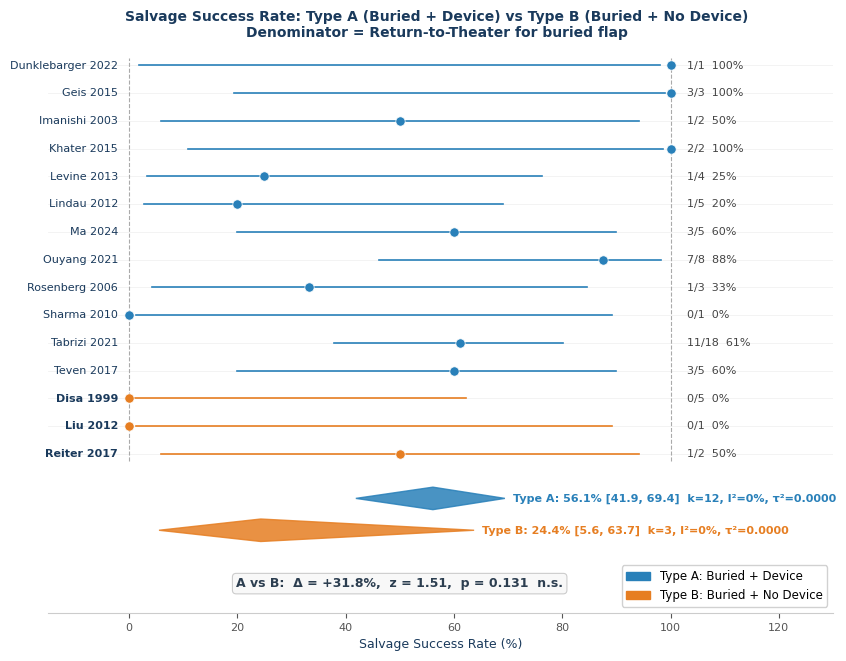

Saved: results_salvage.csv


In [35]:
"""
Analysis Step #4: Salvage Success Rate Analysis
  - Denominator : Reop_buried  (number of re-operations for buried flap)
  - Numerator   : salvage_success_buried
  - Inclusion   : studies with salvage_success_buried NOT NaN AND Reop_buried > 0
  - Type A (k=12) vs Type B (k=3)
  - Method: DerSimonian-Laird random-effects, logit transformation
  - Forest plot: C and D in a single panel, diamonds at bottom
  - Between-group z-test
"""

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── Colours ────────────────────────────────────────────────────────────────────
C_HEADER  = '#1A3A5C'
C_DEVICE  = '#2980B9'   # Type A
C_CONV    = '#E67E22'   # Type B
C_GRID    = '#EEEEEE'

# ── 1. Load & prepare data ─────────────────────────────────────────────────────
df = pd.read_csv('Meta_Data_C_out.csv',
                 na_values=['NA', 'NR', 'Not reported', 'Not Reported'])

# Parse Reop_buried
df['Reop_buried'] = pd.to_numeric(
    df['Reop_buried'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')

# Inclusion filter: salvage_success_buried is numeric AND Reop_buried > 0
def get_salvage(df_in, type_label):
    sub = df_in[
        (df_in['Type'] == type_label) &
        df_in['salvage_success_buried'].notna() &
        df_in['Reop_buried'].notna() &
        (df_in['Reop_buried'] > 0)
    ].copy()
    return sub

dfC_s = get_salvage(df, 'Type A')
dfD_s = get_salvage(df, 'Type B')

print("=== Type A: Salvage data ===")
print(dfC_s[['author','year','Reop_buried','salvage_success_buried']
            ].to_string(index=False))
print()
print("=== Type B: Salvage data ===")
print(dfD_s[['author','year','Reop_buried','salvage_success_buried']
            ].to_string(index=False))

# ── 2. Statistical functions ───────────────────────────────────────────────────
def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

def inv_logit(x):
    return 1 / (1 + np.exp(-x))

def pool_prop(n_events, n_total, labels):
    """DerSimonian-Laird random-effects pooling (logit scale)."""
    n_events = np.array(n_events, dtype=float)
    n_total  = np.array(n_total,  dtype=float)
    ne = n_events.copy(); nt = n_total.copy()
    # Haldane correction for zero cells
    mask0 = (ne == 0)
    ne[mask0] += 0.5; nt[mask0] += 1.0
    # Also correct if all events (ne == nt)
    mask1 = (ne >= nt)
    ne[mask1] = nt[mask1] - 0.5
    p_i  = ne / nt
    lp_i = logit(p_i)
    se_i = np.sqrt(1/ne + 1/(nt - ne))
    w_fe  = 1 / se_i**2
    lp_fe = np.sum(w_fe * lp_i) / np.sum(w_fe)
    Q  = np.sum(w_fe * (lp_i - lp_fe)**2)
    k  = len(lp_i)
    C  = np.sum(w_fe) - np.sum(w_fe**2) / np.sum(w_fe)
    tau2 = max(0.0, (Q - (k - 1)) / C)
    I2   = max(0.0, (Q - (k - 1)) / Q * 100) if Q > 0 else 0.0
    p_Q  = 1 - stats.chi2.cdf(Q, k - 1)
    w_re  = 1 / (se_i**2 + tau2)
    lp_re = np.sum(w_re * lp_i) / np.sum(w_re)
    se_re = np.sqrt(1 / np.sum(w_re))
    pooled   = inv_logit(lp_re)
    ci_lo_95 = inv_logit(lp_re - 1.96 * se_re)
    ci_hi_95 = inv_logit(lp_re + 1.96 * se_re)
    wt_pct   = w_re / np.sum(w_re) * 100
    return dict(
        labels=labels, k=k,
        n_events=n_events, n_total=n_total,
        p_i=p_i, lp_i=lp_i, se_i=se_i, wt_pct=wt_pct,
        lp_re=lp_re, se_re=se_re,
        pooled=pooled, ci_lo_95=ci_lo_95, ci_hi_95=ci_hi_95,
        Q=Q, p_Q=p_Q, tau2=tau2, I2=I2)

def z_test_between(r1, r2):
    z   = (r1['lp_re'] - r2['lp_re']) / np.sqrt(r1['se_re']**2 + r2['se_re']**2)
    p   = 2 * (1 - stats.norm.cdf(abs(z)))
    sig = ('***' if p < 0.001 else '**' if p < 0.01
           else '*' if p < 0.05 else '†' if p < 0.10 else 'n.s.')
    return dict(z=z, p=p, sig=sig,
                diff_pct=(r1['pooled'] - r2['pooled']) * 100)

# ── 3. Pool each group ─────────────────────────────────────────────────────────
rC = pool_prop(
    dfC_s['salvage_success_buried'].values,
    dfC_s['Reop_buried'].values,
    (dfC_s['author'] + ' ' + dfC_s['year'].astype(str)).tolist())

rD = pool_prop(
    dfD_s['salvage_success_buried'].values,
    dfD_s['Reop_buried'].values,
    (dfD_s['author'] + ' ' + dfD_s['year'].astype(str)).tolist())

cmp = z_test_between(rC, rD)

print()
print("=== Pooled Salvage Success Rate ===")
print(f"Type A (k={rC['k']}): {rC['pooled']*100:.1f}% "
      f"[{rC['ci_lo_95']*100:.1f}, {rC['ci_hi_95']*100:.1f}]  "
      f"I²={rC['I2']:.0f}%  τ²={rC['tau2']:.4f}")
print(f"Type B (k={rD['k']}): {rD['pooled']*100:.1f}% "
      f"[{rD['ci_lo_95']*100:.1f}, {rD['ci_hi_95']*100:.1f}]  "
      f"I²={rD['I2']:.0f}%  τ²={rD['tau2']:.4f}")
print(f"C vs D: Δ={cmp['diff_pct']:+.1f}%  z={cmp['z']:.3f}  "
      f"p={cmp['p']:.4f}  {cmp['sig']}")

# ── 4. Forest plot ─────────────────────────────────────────────────────────────
# Build entry list: Type A first, then Type B
entries = []
for _, row in dfC_s.iterrows():
    entries.append(('C', f"{row['author']} {row['year']}",
                    float(row['salvage_success_buried']),
                    float(row['Reop_buried'])))
for _, row in dfD_s.iterrows():
    entries.append(('D', f"{row['author']} {row['year']}",
                    float(row['salvage_success_buried']),
                    float(row['Reop_buried'])))

k_total = len(entries)
k_c     = len(dfC_s)
y_step = 0.74
y_pos = np.arange(k_total, 0, -1, dtype=float) * y_step

fig, ax = plt.subplots(figsize=(9, max(6.5, k_total * 0.24 + 3.2)),
                       facecolor='white')

# Grid
for yy in y_pos:
    ax.axhline(yy, color=C_GRID, lw=0.5, zorder=0)
y_top = y_pos[0] + 0.2
y_bot = y_pos[-1] - 0.2
ax.plot([0, 0], [y_bot, y_top], color='#AAAAAA', lw=0.8, ls='--', zorder=1)
ax.plot([100, 100], [y_bot, y_top], color='#AAAAAA', lw=0.8, ls='--', zorder=1)

# Per-study points
for i, (typ, lbl, ne, nt) in enumerate(entries):
    y    = y_pos[i]
    ne_c = ne + 0.5 if ne == 0 else ne
    nt_c = nt + 1.0 if ne == 0 else nt
    ne_c = min(ne_c, nt_c - 0.5)   # guard against ne==nt
    p_i  = ne_c / nt_c
    lp   = logit(p_i)
    se   = np.sqrt(1/ne_c + 1/(nt_c - ne_c))
    lo   = inv_logit(lp - 1.96 * se) * 100
    hi   = inv_logit(lp + 1.96 * se) * 100
    pc   = ne / nt * 100           # raw rate for display
    c_pt = C_DEVICE if typ == 'C' else C_CONV
    ax.plot([lo, hi], [y, y], color=c_pt, lw=1.2, zorder=2)
    ax.scatter(pc, y, s=45, color=c_pt, zorder=3,
               edgecolors='white', linewidths=0.5)
    ax.text(-2, y, lbl, ha='right', va='center', fontsize=8,
            color=C_HEADER,
            fontweight='bold' if typ == 'D' else 'normal')
    ax.text(103, y, f'{int(ne)}/{int(nt)}  {pc:.0f}%',
            ha='left', va='center', fontsize=8, color='#444444')


# Pooled diamonds
dh = 0.30
for r, typ, y_d in [(rC, 'C', -0.45), (rD, 'D', -1.30)]:
    cx   = r['pooled'] * 100
    lo95 = r['ci_lo_95'] * 100
    hi95 = r['ci_hi_95'] * 100
    c_d  = C_DEVICE if typ == 'C' else C_CONV
    ax.add_patch(plt.Polygon(
        [[lo95, y_d], [cx, y_d + dh], [hi95, y_d], [cx, y_d - dh]],
        closed=True, color=c_d, zorder=4, alpha=0.85))
    lbl_t = 'A' if typ == 'C' else 'B'
    ax.text(min(hi95 + 1.5, 98), y_d,
            f'Type {lbl_t}: {cx:.1f}% [{lo95:.1f}, {hi95:.1f}]  '
            f'k={r["k"]}, I²={r["I2"]:.0f}%, τ²={r["tau2"]:.4f}',
            ha='left', va='center', fontsize=8, color=c_d,
            fontweight='bold')

# z-test annotation
ax.text(50, -2.55,
        f'A vs B:  Δ = {cmp["diff_pct"]:+.1f}%,  '
        f'z = {cmp["z"]:.2f},  p = {cmp["p"]:.3f}  {cmp["sig"]}',
        ha='center', va='top', fontsize=9, color='#2C3E50',
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', fc='#F8F8F8',
                  ec='#CCCCCC', lw=0.8))

# Legend
legend_handles = [
    mpatches.Patch(color=C_DEVICE, label='Type A: Buried + Device'),
    mpatches.Patch(color=C_CONV,   label='Type B: Buried + No Device'),
]
ax.legend(handles=legend_handles, loc='lower right',
          fontsize=8.5, framealpha=0.9)

ax.set_xlim(-15, 130)
ax.set_ylim(-3.5, y_pos[0] + 0.45)
ax.set_xlabel('Salvage Success Rate (%)', fontsize=9, color=C_HEADER)
ax.set_yticks([])
for sp in ['top', 'right', 'left']:
    ax.spines[sp].set_visible(False)
ax.spines['bottom'].set_color('#CCCCCC')
ax.tick_params(axis='x', colors='#555555', labelsize=8)

fig.text(
    0.5, 0.965,
    'Salvage Success Rate: Type A (Buried + Device) vs Type B (Buried + No Device)\n'
    'Denominator = Return-to-Theater for buried flap',
    ha='center',va='top', fontsize=10, fontweight='bold', color=C_HEADER
    )

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('fig5_salvage.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.savefig('fig5_salvage.pdf', bbox_inches='tight', facecolor='white')
print('\nSaved: fig5_salvage.png / .pdf')
plt.show()

# ── 5. Export CSV ──────────────────────────────────────────────────────────────
rows = []
for r, typ in [(rC, 'Type A'), (rD, 'Type B')]:
    rows.append(dict(
        Group=typ, k=r['k'],
        Pooled_pct=round(r['pooled']*100, 2),
        CI95_Lo=round(r['ci_lo_95']*100, 2),
        CI95_Hi=round(r['ci_hi_95']*100, 2),
        I2_pct=round(r['I2'], 1),
        Q=round(r['Q'], 3), p_Q=round(r['p_Q'], 4),
        tau2=round(r['tau2'], 4),
        z=round(cmp['z'], 3),
        p_value=round(cmp['p'], 4),
        Sig=cmp['sig']))

pd.DataFrame(rows).to_csv('results_salvage.csv', index=False)
print('Saved: results_salvage.csv')

=== Case A: FP / Reop_buried (Reop > 0 only) ===
      author  year        Device  Reop_buried  FP_Reop_buried
    Chadwick  2020           IDP          1.0             1.0
Dunklebarger  2022           IDP          1.0             0.0
        Geis  2015 Color Doppler          3.0             0.0
    Imanishi  2003         Other          2.0             0.0
      Khater  2015         Other          2.0             0.0
      Lindau  2012           IDP          5.0             0.0
          Ma  2024          NIRS          5.0             0.0
      Ouyang  2021          NIRS          8.0             0.0
   Rosenberg  2006           IDP          3.0             2.0
      Sharma  2010 Color Doppler          1.0             0.0
       Teven  2017           IDP          5.0             2.0
k = 11

=== Case B: FP / total_flap_n_buried ===
        author  year        Device  total_flap_n_buried  FP_Reop_buried
           Cai  2008          NIRS                   41             0.0
      Chadwick

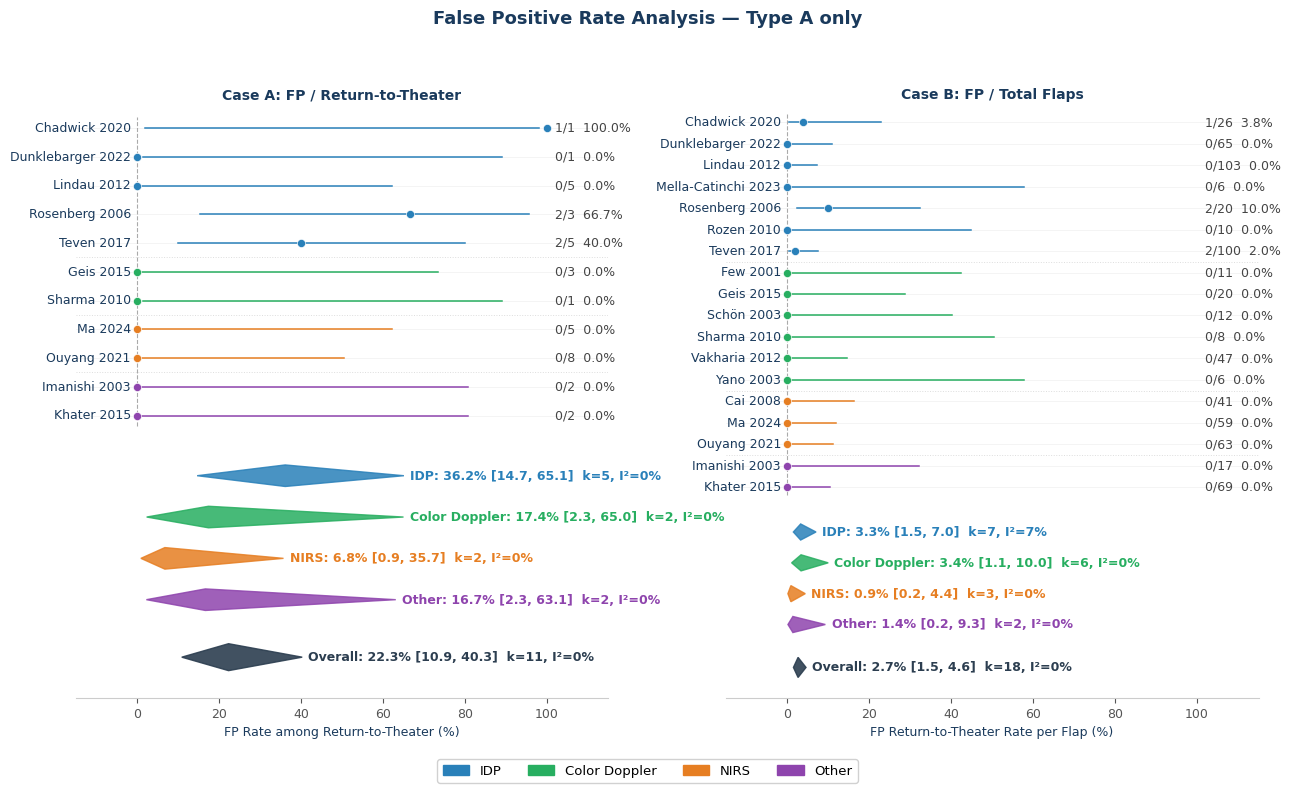


=== Device-level pooled FP rate (Case A) ===
       Device  k  Pooled_pct  CI95_Lo  CI95_Hi  I2_pct
          IDP  5       36.15    14.66    65.12     0.0
Color Doppler  2       17.44     2.34    65.01     0.0
         NIRS  2        6.79     0.95    35.73     0.0
        Other  2       16.67     2.28    63.13     0.0
Saved: fig7_fp_device.png / .pdf


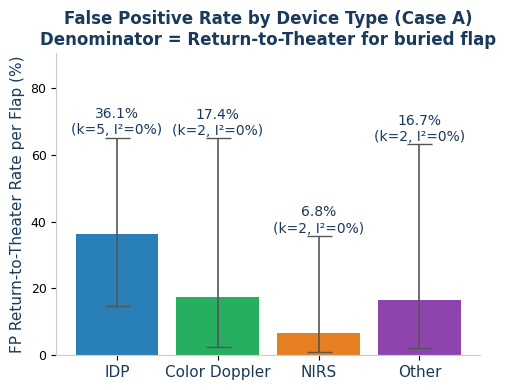

Saved: results_fp.csv

=== Summary ===
Case A (FP/Return-to-Theater, k=11): 22.3% [10.9, 40.3]  I²=0%
Case B (FP/total, k=18): 2.7% [1.5, 4.6]  I²=0%


In [43]:
"""
Analysis Step #5: False Positive (FP) Rate Analysis — Type A only
  Column: FP_Reop_buried (number of FP re-operations for buried flap)
  Exclusion: Levine 2013, Tabrizi 2021 (FP_Reop_buried = NaN)

  Case A: denominator = Reop_buried  (FP rate among all re-operations)
          Inclusion: FP_Reop_buried NOT NaN AND Reop_buried > 0  → k=11
          Studies with Reop=0 are excluded (0/0 undefined)

  Case B: denominator = total_flap_n_buried  (FP re-operation rate per flap)
          Inclusion: FP_Reop_buried NOT NaN  → k=18
          Studies with FP=0 and Reop=0 contribute 0/N

  Method: DerSimonian-Laird random-effects, logit transformation
  Outputs:
    fig_fp_caseA.png  — Forest plot, denominator = Reop_buried
    fig_fp_caseB.png  — Forest plot, denominator = total_flap_n_buried
    fig_fp_device.png — Bar chart: pooled FP rate by device (Case A)
    results_fp.csv
"""

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── Colours ────────────────────────────────────────────────────────────────────
C_HEADER = '#1A3A5C'
C_DEVICE = '#2980B9'
C_GRID   = '#EEEEEE'
DEVICE_COLORS = {
    'IDP':           '#2980B9',
    'Color Doppler': '#27AE60',
    'NIRS':          '#E67E22',
    'Other':         '#8E44AD',
}
DEVICE_ORDER = ['IDP', 'Color Doppler', 'NIRS', 'Other']

# ── 1. Load & prepare data ─────────────────────────────────────────────────────
df = pd.read_csv('Meta_Data_C_out.csv',
                 na_values=['NA', 'NR', 'Not reported', 'Not Reported'])

df['Reop_buried'] = pd.to_numeric(
    df['Reop_buried'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')

dfC = df[df['Type'] == 'Type A'].copy().reset_index(drop=True)

# ── 2. Statistical functions ───────────────────────────────────────────────────
def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

def inv_logit(x):
    return 1 / (1 + np.exp(-x))

def pool_prop(n_events, n_total, labels):
    """DerSimonian-Laird random-effects pooling (logit scale)."""
    n_events = np.array(n_events, dtype=float)
    n_total  = np.array(n_total,  dtype=float)
    ne = n_events.copy(); nt = n_total.copy()
    mask0 = (ne == 0)
    ne[mask0] += 0.5; nt[mask0] += 1.0
    p_i  = ne / nt
    lp_i = logit(p_i)
    se_i = np.sqrt(1/ne + 1/(nt - ne))
    w_fe  = 1 / se_i**2
    lp_fe = np.sum(w_fe * lp_i) / np.sum(w_fe)
    Q  = np.sum(w_fe * (lp_i - lp_fe)**2)
    k  = len(lp_i)
    C  = np.sum(w_fe) - np.sum(w_fe**2) / np.sum(w_fe)
    tau2 = max(0.0, (Q - (k - 1)) / C)
    I2   = max(0.0, (Q - (k - 1)) / Q * 100) if Q > 0 else 0.0
    p_Q  = 1 - stats.chi2.cdf(Q, k - 1)
    w_re  = 1 / (se_i**2 + tau2)
    lp_re = np.sum(w_re * lp_i) / np.sum(w_re)
    se_re = np.sqrt(1 / np.sum(w_re))
    pooled   = inv_logit(lp_re)
    ci_lo_95 = inv_logit(lp_re - 1.96 * se_re)
    ci_hi_95 = inv_logit(lp_re + 1.96 * se_re)
    wt_pct   = w_re / np.sum(w_re) * 100
    return dict(
        labels=labels, k=k,
        n_events=n_events, n_total=n_total,
        p_i=p_i, lp_i=lp_i, se_i=se_i, wt_pct=wt_pct,
        lp_re=lp_re, se_re=se_re,
        pooled=pooled, ci_lo_95=ci_lo_95, ci_hi_95=ci_hi_95,
        Q=Q, p_Q=p_Q, tau2=tau2, I2=I2)

# ── 3. Forest plot helper ──────────────────────────────────────────────────────
def forest_fp(ax, sub, ev_col, n_col, title, x_label):
    entries = []

    for _, row in sub.iterrows():
        entries.append((
            row['Device'],
            f"{row['author']} {row['year']}",
            float(row[ev_col]),
            float(row[n_col])
        ))

    dev_rank = {d: i for i, d in enumerate(DEVICE_ORDER)}
    entries.sort(key=lambda x: dev_rank.get(x[0], 99))

    k_total = len(entries)

    # compact spacing
    y_step = 0.32
    y_pos = np.arange(k_total, 0, -1, dtype=float) * y_step

    for yy in y_pos:
        ax.axhline(yy, color=C_GRID, lw=0.45, zorder=0)

    y_top = y_pos[0] + 0.12
    y_bot = y_pos[-1] - 0.12
    ax.plot([0, 0], [y_bot, y_top], color='#AAAAAA',
            lw=0.8, ls='--', zorder=1)

    prev_dev = None

    for i, (dev, lbl, ne, nt) in enumerate(entries):
        y = y_pos[i]

        if dev != prev_dev and i > 0:
            ax.axhline(y + y_step / 2, color='#DDDDDD',
                       lw=0.7, ls=':', zorder=3)

        prev_dev = dev

        ne_c = ne + 0.5 if ne == 0 else ne
        nt_c = nt + 1.0 if ne == 0 else nt

        if ne_c >= nt_c:
            ne_c = nt_c - 0.5

        p_i = ne_c / nt_c
        lp = logit(p_i)
        se = np.sqrt(1 / ne_c + 1 / (nt_c - ne_c))

        lo = inv_logit(lp - 1.96 * se) * 100
        hi = inv_logit(lp + 1.96 * se) * 100
        pc = ne / nt * 100

        c_pt = DEVICE_COLORS.get(dev, '#555555')

        ax.plot([lo, hi], [y, y], color=c_pt, lw=1.1, zorder=2)
        ax.scatter(pc, y, s=34, color=c_pt, zorder=3,
                   edgecolors='white', linewidths=0.45)

        ax.text(-1.5, y, lbl,
                ha='right', va='center',
                fontsize=9, color=C_HEADER)

        ax.text(102, y, f'{int(ne)}/{int(nt)}  {pc:.1f}%',
                ha='left', va='center',
                fontsize=9, color='#444444')

    # Pooled diamonds per device + overall
    pool_all = []
    diamond_y = -0.35
    diamond_step = 0.46
    dh = 0.12

    for dev in DEVICE_ORDER:
        dev_ents = [
            (ne, nt, lbl)
            for d, lbl, ne, nt in entries
            if d == dev
        ]

        if len(dev_ents) < 2:
            continue

        ne_arr = np.array([x[0] for x in dev_ents])
        nt_arr = np.array([x[1] for x in dev_ents])
        lb_arr = [x[2] for x in dev_ents]

        r = pool_prop(ne_arr, nt_arr, lb_arr)
        pool_all.append((dev, r))

        cx = r['pooled'] * 100
        lo95 = r['ci_lo_95'] * 100
        hi95 = r['ci_hi_95'] * 100
        c_d = DEVICE_COLORS[dev]

        ax.add_patch(plt.Polygon(
            [
                [lo95, diamond_y],
                [cx, diamond_y + dh],
                [hi95, diamond_y],
                [cx, diamond_y - dh]
            ],
            closed=True,
            color=c_d,
            zorder=4,
            alpha=0.85
        ))

        # text moved to the right of diamond
        ax.text(
            min(hi95 + 1.5, 104),
            diamond_y,
            f"{dev}: {cx:.1f}% [{lo95:.1f}, {hi95:.1f}]  "
            f"k={r['k']}, I²={r['I2']:.0f}%",
            ha='left',
            va='center',
            fontsize=9,
            color=c_d,
            fontweight='bold'
        )

        diamond_y -= diamond_step

    # Overall
    all_ne = np.array([x[2] for x in entries])
    all_nt = np.array([x[3] for x in entries])
    all_lb = [x[1] for x in entries]

    r_all = pool_prop(all_ne, all_nt, all_lb)

    cx_a = r_all['pooled'] * 100
    lo_a = r_all['ci_lo_95'] * 100
    hi_a = r_all['ci_hi_95'] * 100

    diamond_y -= 0.18

    ax.add_patch(plt.Polygon(
        [
            [lo_a, diamond_y],
            [cx_a, diamond_y + dh + 0.03],
            [hi_a, diamond_y],
            [cx_a, diamond_y - dh - 0.03]
        ],
        closed=True,
        color='#2C3E50',
        zorder=5,
        alpha=0.9
    ))

    ax.text(
        min(hi_a + 1.5, 104),
        diamond_y,
        f"Overall: {cx_a:.1f}% [{lo_a:.1f}, {hi_a:.1f}]  "
        f"k={r_all['k']}, I²={r_all['I2']:.0f}%",
        ha='left',
        va='center',
        fontsize=9,
        color='#2C3E50',
        fontweight='bold'
    )

    ax.set_xlim(-15, 115)
    ax.set_ylim(diamond_y - 0.45, y_pos[0] + 0.25)

    ax.set_xlabel(x_label, fontsize=9, color=C_HEADER)
    ax.set_yticks([])

    for sp in ['top', 'right', 'left']:
        ax.spines[sp].set_visible(False)

    ax.spines['bottom'].set_color('#CCCCCC')
    ax.tick_params(axis='x', colors='#555555', labelsize=9)

    ax.set_title(title, fontsize=10, fontweight='bold',
                 color=C_HEADER, pad=5)

    return r_all


# ── 4. Case A and Case B: combined 1×2 forest plot ─────────────────────────────
subA = dfC[
    dfC['FP_Reop_buried'].notna() &
    dfC['Reop_buried'].notna() &
    (dfC['Reop_buried'] > 0)
].copy()

print("=== Case A: FP / Reop_buried (Reop > 0 only) ===")
print(subA[['author', 'year', 'Device', 'Reop_buried', 'FP_Reop_buried']]
      .to_string(index=False))
print(f"k = {len(subA)}")

subB = dfC[
    dfC['FP_Reop_buried'].notna() &
    dfC['total_flap_n_buried'].notna()
].copy()

print()
print("=== Case B: FP / total_flap_n_buried ===")
print(subB[['author', 'year', 'Device', 'total_flap_n_buried', 'FP_Reop_buried']]
      .to_string(index=False))
print(f"k = {len(subB)}")

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 8),
    facecolor='white'
)

r_all_A = forest_fp(
    axes[0],
    subA,
    ev_col='FP_Reop_buried',
    n_col='Reop_buried',
    title='Case A: FP / Return-to-Theater',
    x_label='FP Rate among Return-to-Theater (%)'
)

r_all_B = forest_fp(
    axes[1],
    subB,
    ev_col='FP_Reop_buried',
    n_col='total_flap_n_buried',
    title='Case B: FP / Total Flaps',
    x_label='FP Return-to-Theater Rate per Flap (%)'
)

legend_handles = [
    mpatches.Patch(color=DEVICE_COLORS[d], label=d)
    for d in DEVICE_ORDER
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=4,
    fontsize=9.5,
    framealpha=0.9,
    title_fontsize=9.5,
    bbox_to_anchor=(0.5, 0.005)
)

fig.suptitle(
    'False Positive Rate Analysis — Type A only',
    fontsize=13,
    fontweight='bold',
    color=C_HEADER,
    y=0.98
)

plt.subplots_adjust(
    left=0.06,
    right=0.97,
    top=0.86,
    bottom=0.12,
    wspace=0.22
)

plt.savefig(
    'fig6_fp_combined_1x2.png',
    dpi=600,
    bbox_inches='tight',
    facecolor='white'
)
plt.savefig(
    'fig6_fp_combined_1x2.pdf',
    bbox_inches='tight',
    facecolor='white'
)
print('Saved: fig6_fp_combined_1x2.png / .pdf')
plt.show()

# ── 6. Bar chart: pooled FP rate by device (Case A) ───────────────────────────
dev_pool_rows = []
for dev in DEVICE_ORDER:
    sub_d = subA[subA['Device'] == dev]
    if len(sub_d) == 0:
        continue
    ne_arr = sub_d['FP_Reop_buried'].values.astype(float)
    nt_arr = sub_d['Reop_buried'].values.astype(float)
    lb_arr = (sub_d['author'] + ' ' + sub_d['year'].astype(str)).tolist()
    if len(sub_d) >= 2:
        r = pool_prop(ne_arr, nt_arr, lb_arr)
        dev_pool_rows.append(dict(
            Device=dev, k=r['k'],
            Pooled_pct=round(r['pooled']*100, 2),
            CI95_Lo=round(r['ci_lo_95']*100, 2),
            CI95_Hi=round(r['ci_hi_95']*100, 2),
            I2_pct=round(r['I2'], 1)))
    else:
        p_s = ne_arr[0] / nt_arr[0]
        dev_pool_rows.append(dict(
            Device=dev, k=1,
            Pooled_pct=round(p_s*100, 2),
            CI95_Lo=None, CI95_Hi=None, I2_pct=None))

df_dev = pd.DataFrame(dev_pool_rows)
print()
print("=== Device-level pooled FP rate (Case A) ===")
print(df_dev.to_string(index=False))

fig3, ax3 = plt.subplots(figsize=(5, 4), facecolor='white')
x = np.arange(len(df_dev))
colors = [DEVICE_COLORS.get(d, '#555555') for d in df_dev['Device']]
yerr_lo = [row['Pooled_pct'] - row['CI95_Lo']
           if row['CI95_Lo'] is not None else 0
           for _, row in df_dev.iterrows()]
yerr_hi = [row['CI95_Hi'] - row['Pooled_pct']
           if row['CI95_Hi'] is not None else 0
           for _, row in df_dev.iterrows()]
bars = ax3.bar(x, df_dev['Pooled_pct'],
               yerr=[yerr_lo, yerr_hi],
               color=colors, width=0.82, capsize=9,
               error_kw=dict(elinewidth=1.2, ecolor='#555555'))
for bar, row in zip(bars, df_dev.itertuples()):
    i2_str = f', I²={row.I2_pct:.0f}%' if row.I2_pct is not None else ''
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (row.CI95_Hi - row.Pooled_pct
                                 if row.CI95_Hi else 0) + 0.05,
             f'{row.Pooled_pct:.1f}%\n(k={row.k}{i2_str})',
             ha='center', va='bottom', fontsize=10, color=C_HEADER)
ax3.set_xticks(x)
ax3.set_xticklabels(df_dev['Device'], fontsize=11, color=C_HEADER)
ax3.set_ylabel('FP Return-to-Theater Rate per Flap (%)', fontsize=11, color=C_HEADER)
ax3.tick_params(axis='y', labelsize=9)
ax3.set_title('False Positive Rate by Device Type (Case A)\n'
              'Denominator = Return-to-Theater for buried flap',
              fontsize=12, fontweight='bold', color=C_HEADER)
ax3.set_ylim(0, max(df_dev['Pooled_pct']) * 2.5)
ax3.axhline(0, color='#CCCCCC', lw=0.8)
for sp in ['top', 'right']:
    ax3.spines[sp].set_visible(False)
ax3.spines['left'].set_color('#CCCCCC')
ax3.spines['bottom'].set_color('#CCCCCC')
plt.tight_layout()
fig3.savefig('fig7_fp_device.png', dpi=600, bbox_inches='tight', facecolor='white')
fig3.savefig('fig7_fp_device.pdf', bbox_inches='tight', facecolor='white')
print('Saved: fig7_fp_device.png / .pdf')
plt.show()

# ── 7. Export CSV ──────────────────────────────────────────────────────────────
rows_out = []

# Case A overall
rows_out.append(dict(
    Case='A (denom=Reop_buried)', Group='Overall', k=r_all_A['k'],
    Pooled_pct=round(r_all_A['pooled']*100, 2),
    CI95_Lo=round(r_all_A['ci_lo_95']*100, 2),
    CI95_Hi=round(r_all_A['ci_hi_95']*100, 2),
    I2_pct=round(r_all_A['I2'], 1),
    Q=round(r_all_A['Q'], 3), p_Q=round(r_all_A['p_Q'], 4),
    tau2=round(r_all_A['tau2'], 4)))

# Case B overall
rows_out.append(dict(
    Case='B (denom=total_flap_n)', Group='Overall', k=r_all_B['k'],
    Pooled_pct=round(r_all_B['pooled']*100, 2),
    CI95_Lo=round(r_all_B['ci_lo_95']*100, 2),
    CI95_Hi=round(r_all_B['ci_hi_95']*100, 2),
    I2_pct=round(r_all_B['I2'], 1),
    Q=round(r_all_B['Q'], 3), p_Q=round(r_all_B['p_Q'], 4),
    tau2=round(r_all_B['tau2'], 4)))

# Case A by device
for row in dev_pool_rows:
    rows_out.append(dict(
        Case='A (denom=Reop_buried)', Group=row['Device'], k=row['k'],
        Pooled_pct=row['Pooled_pct'],
        CI95_Lo=row['CI95_Lo'], CI95_Hi=row['CI95_Hi'],
        I2_pct=row['I2_pct'],
        Q=None, p_Q=None, tau2=None))

pd.DataFrame(rows_out).to_csv('results_fp.csv', index=False)
print('Saved: results_fp.csv')

print()
print("=== Summary ===")
print(f"Case A (FP/Return-to-Theater, k={r_all_A['k']}): "
      f"{r_all_A['pooled']*100:.1f}% "
      f"[{r_all_A['ci_lo_95']*100:.1f}, {r_all_A['ci_hi_95']*100:.1f}]  "
      f"I²={r_all_A['I2']:.0f}%")
print(f"Case B (FP/total, k={r_all_B['k']}): "
      f"{r_all_B['pooled']*100:.1f}% "
      f"[{r_all_B['ci_lo_95']*100:.1f}, {r_all_B['ci_hi_95']*100:.1f}]  "
      f"I²={r_all_B['I2']:.0f}%")

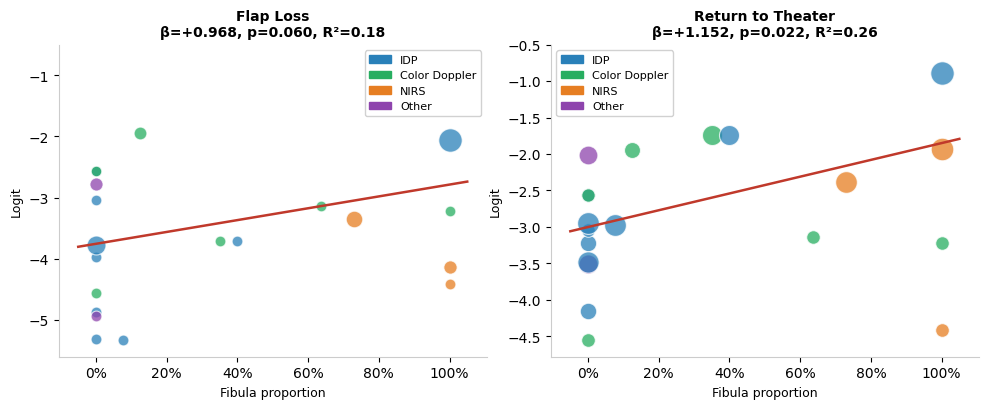

Saved: fig8_metareg_flaptype_combined.png


In [47]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def bubble_plot_ax(ax, sub, x_vals, x_label, y_lp, w_re, beta,
                   x_range, color_by_device, title, x_tick_fmt=None):

    ax.axhline(0, color='#CCCCCC', lw=0.8, ls='--')

    for i, row in sub.iterrows():
        idx = sub.index.get_loc(i)
        xv  = x_vals[idx]
        yv  = y_lp[idx]
        sz  = w_re[idx] / np.max(w_re) * 260 + 25

        c = DEVICE_COLORS.get(row['Device'], '#555555') if color_by_device else C_HEADER

        ax.scatter(xv, yv, s=sz, color=c, alpha=0.75,
                   edgecolors='white', linewidths=0.8, zorder=3)

    # regression line
    x_line = np.linspace(x_range[0], x_range[1], 200)
    y_line = beta[0] + beta[1] * x_line
    ax.plot(x_line, y_line, color='#C0392B', lw=1.8, zorder=4)

    if color_by_device:
        handles = [
            mpatches.Patch(color=DEVICE_COLORS[d], label=d)
            for d in DEVICE_COLORS if d in sub['Device'].values
        ]
        ax.legend(handles=handles, fontsize=8, framealpha=0.9)

    ax.set_xlabel(x_label, fontsize=9)
    ax.set_ylabel('Logit', fontsize=9)

    if x_tick_fmt == 'pct':
        ax.xaxis.set_major_formatter(
            plt.FuncFormatter(lambda v, _: f'{v*100:.0f}%'))

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylim(bottom=ax.get_ylim()[0], top=-0.5)

    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)

    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')

fig, axes = plt.subplots(1, 2, figsize=(10, 4), facecolor='white')

for i, (ev_col, n_col, outcome_label) in enumerate([
    ('flap_loss_buried', 'total_flap_n_buried', 'Flap Loss'),
    ('Reop_buried', 'total_flap_n_buried', 'Return to Theater')
]):

    sub = dfC.dropna(subset=[ev_col, n_col]).copy()
    sub = sub[sub[n_col] > 0].reset_index(drop=True)

    lp, se, w, tau2, I2 = prepare_outcome(sub, ev_col, n_col)

    # Fibula proportion
    sub['fibula_pct'] = sub['Fibula_bd'].fillna(0) / sub[n_col]

    X = np.column_stack([np.ones(len(sub)), sub['fibula_pct'].values])
    beta, se_b, t, p, R2 = wls_metareg(lp, X, w)

    bubble_plot_ax(
        axes[i],
        sub,
        sub['fibula_pct'].values,
        'Fibula proportion',
        lp,
        w,
        beta,
        x_range=(-0.05, sub['fibula_pct'].max() + 0.05),
        color_by_device=True,
        title=f'{outcome_label}\nβ={beta[1]:+.3f}, p={p[1]:.3f}, R²={R2:.2f}',
        x_tick_fmt='pct'
    )

# spacing tight
plt.subplots_adjust(
    left=0.06,
    right=0.98,
    top=0.90,
    bottom=0.12,
    wspace=0.15
)

plt.savefig(
    'fig8_metareg_flaptype_combined.png',
    dpi=600,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()
print('Saved: fig8_metareg_flaptype_combined.png')



Outcome: Flap Loss Rate  (k=20)

Outcome: Return to Theater Rate  (k=20)
Saved: fig10_loo_combined_1x2.png


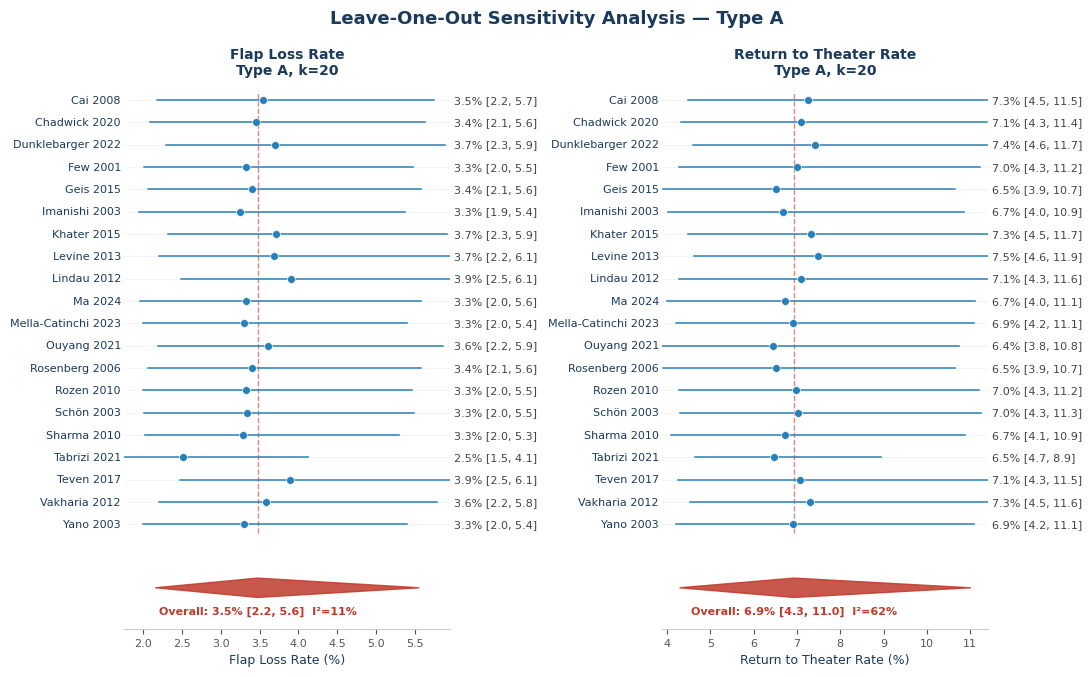


Flap Loss Rate
  Begg's rank correlation: τ=0.2766, p=0.0909 †
  Egger's test: intercept=-2.0185 (SE=0.5168), t=-3.905, p=0.0010 **

Return to Theater Rate
  Begg's rank correlation: τ=-0.1064, p=0.5155 n.s.
  Egger's test: intercept=-4.4064 (SE=1.0197), t=-4.321, p=0.0004 ***
Saved: fig11_funnel_combined_1x2.png


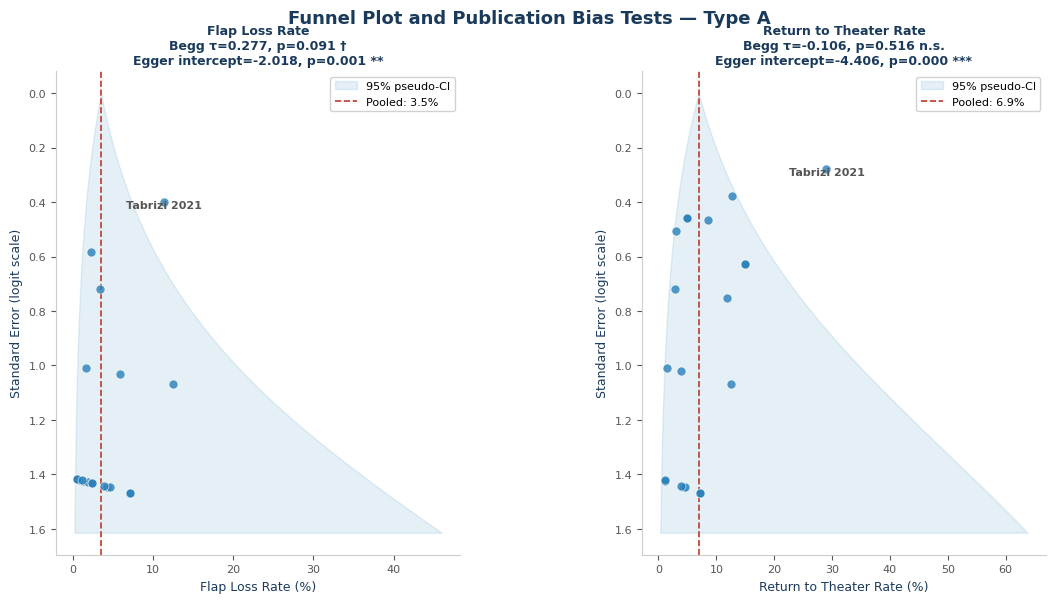

In [46]:
"""
Analysis Step #7: Sensitivity Analysis & Publication Bias — Type A (k=20)
  Outcomes: (1) Flap Loss Rate  (2) Return to Theater Rate

  7a. Leave-one-out (LOO) sensitivity analysis
      → Forest plot of LOO pooled estimates with overall diamond

  7b. Publication bias
      → Funnel plot (SE vs logit proportion)
      → Begg's rank correlation test (Kendall's τ)
      → Egger's weighted regression test

  Output:
    fig_loo_flaploss.png
    fig_loo_reop.png
    fig_funnel_flaploss.png
    fig_funnel_reop.png
    results_sensitivity.csv
"""

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── Colours ────────────────────────────────────────────────────────────────────
C_HEADER  = '#1A3A5C'
C_DEVICE  = '#2980B9'
C_OVERALL = '#C0392B'
C_GRID    = '#EEEEEE'

# ── 1. Load & prepare data ─────────────────────────────────────────────────────
df = pd.read_csv('Meta_Data_C_out.csv',
                 na_values=['NA', 'NR', 'Not reported', 'Not Reported'])

df['Reop_buried'] = pd.to_numeric(
    df['Reop_buried'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')

dfC = df[df['Type'] == 'Type A'].copy().reset_index(drop=True)

# ── 2. Statistical helpers ─────────────────────────────────────────────────────
def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

def inv_logit(x):
    return 1 / (1 + np.exp(-x))

def dl_pool(ne_arr, nt_arr):
    """Full DL random-effects pooling. Returns (pooled, ci_lo, ci_hi, lp_re, se_re, tau2, I2, Q)."""
    ne = ne_arr.copy().astype(float)
    nt = nt_arr.copy().astype(float)
    mask0 = (ne == 0)
    ne[mask0] += 0.5; nt[mask0] += 1.0
    p_i  = ne / nt
    lp_i = logit(p_i)
    se_i = np.sqrt(1/ne + 1/(nt - ne))
    w_fe  = 1 / se_i**2
    lp_fe = np.sum(w_fe * lp_i) / np.sum(w_fe)
    Q  = np.sum(w_fe * (lp_i - lp_fe)**2)
    k  = len(lp_i)
    C  = np.sum(w_fe) - np.sum(w_fe**2) / np.sum(w_fe)
    tau2 = max(0.0, (Q - (k - 1)) / C)
    I2   = max(0.0, (Q - (k - 1)) / Q * 100) if Q > 0 else 0.0
    w_re  = 1 / (se_i**2 + tau2)
    lp_re = np.sum(w_re * lp_i) / np.sum(w_re)
    se_re = np.sqrt(1 / np.sum(w_re))
    pooled   = inv_logit(lp_re)
    ci_lo    = inv_logit(lp_re - 1.96 * se_re)
    ci_hi    = inv_logit(lp_re + 1.96 * se_re)
    return pooled, ci_lo, ci_hi, lp_re, se_re, tau2, I2, Q

# ── 3. Leave-one-out analysis ──────────────────────────────────────────────────
def run_loo_ax(ax, sub, ev_col, n_col, outcome_label):
    ne_all = sub[ev_col].values.astype(float)
    nt_all = sub[n_col].values.astype(float)
    labels = (sub['author'] + ' ' + sub['year'].astype(str)).tolist()
    k = len(sub)

    p_ov, lo_ov, hi_ov, lp_ov, se_ov, tau2_ov, I2_ov, Q_ov = dl_pool(ne_all, nt_all)

    loo_results = []
    for i in range(k):
        idx = [j for j in range(k) if j != i]
        p_i, lo_i, hi_i, *_ = dl_pool(ne_all[idx], nt_all[idx])
        loo_results.append((labels[i], p_i * 100, lo_i * 100, hi_i * 100))

    # compact spacing
    y_step = 0.30
    y_pos = np.arange(k, 0, -1, dtype=float) * y_step

    x_vals = [pc for _, pc, _, _ in loo_results] + [lo_ov * 100, hi_ov * 100, p_ov * 100]
    x_min_data = min(x_vals)
    x_max_data = max(x_vals)
    x_span = max(10.0, x_max_data - x_min_data)

    # データ範囲はバーだけが収まる最小限のスペース
    # 左右のラベルはデータ座標ではなく axes 座標（0–1）で配置するため
    # x_left/x_right はバーの表示範囲のみ考慮すればよい
    x_left  = x_min_data - 0.04 * x_span
    x_right = x_max_data + 0.04 * x_span

    for yy in y_pos:
        ax.axhline(yy, color=C_GRID, lw=0.45, zorder=0)

    y_top = y_pos[0] + 0.12
    y_bot = y_pos[-1] - 0.12

    ax.plot(
        [p_ov * 100, p_ov * 100],
        [y_bot, y_top],
        color=C_OVERALL,
        lw=1.0,
        ls='--',
        alpha=0.6,
        zorder=1,
        label=f'Overall: {p_ov * 100:.1f}%'
    )

    for i, (lbl, pc, lo, hi) in enumerate(loo_results):
        y = y_pos[i]

        ax.plot([lo, hi], [y, y], color=C_DEVICE, lw=1.1, zorder=2)
        ax.scatter(
            pc, y,
            s=32,
            color=C_DEVICE,
            zorder=3,
            edgecolors='white',
            linewidths=0.45
        )

        # 左ラベル: author名のみ（"Omitting" を削除）
        # get_yaxis_transform() により x は axes 比率(0-1)、y はデータ座標
        ax.text(
            -0.01, y,
            lbl,
            ha='right',
            va='center',
            fontsize=8,
            color=C_HEADER,
            transform=ax.get_yaxis_transform()
        )

        # 右ラベル: 計算結果をプロット領域の右外に配置
        ax.text(
            1.01, y,
            f'{pc:.1f}% [{lo:.1f}, {hi:.1f}]',
            ha='left',
            va='center',
            fontsize=8,
            color='#444444',
            transform=ax.get_yaxis_transform()
        )

    # FIX 3: ダイヤモンドとその説明テキストをx軸から十分離す
    dh = 0.13
    y_d = -0.55           # 元: -0.35 → さらに下げてテキスト用スペース確保
    cx = p_ov * 100
    lo95 = lo_ov * 100
    hi95 = hi_ov * 100

    ax.add_patch(plt.Polygon(
        [[lo95, y_d], [cx, y_d + dh], [hi95, y_d], [cx, y_d - dh]],
        closed=True,
        color=C_OVERALL,
        zorder=4,
        alpha=0.85
    ))

    # FIX 3: ダイヤモンドの下にテキストを配置（ダイヤモンド中心より dh+0.12 下）
    ax.text(
        cx,
        y_d - dh - 0.12,   # ダイヤモンド下端よりさらに下
        f'Overall: {cx:.1f}% [{lo95:.1f}, {hi95:.1f}]  I²={I2_ov:.0f}%',
        ha='center',
        va='top',
        fontsize=8,
        color=C_OVERALL,
        fontweight='bold'
    )

    ax.set_xlim(x_left, x_right)
    # FIX 3: y軸下限をダイヤモンドテキストが収まるよう拡張
    ax.set_ylim(y_d - 0.55, y_pos[0] + 0.25)

    ax.set_xlabel(f'{outcome_label} (%)', fontsize=9, color=C_HEADER)
    ax.set_yticks([])

    for sp in ['top', 'right', 'left']:
        ax.spines[sp].set_visible(False)

    ax.spines['bottom'].set_color('#CCCCCC')
    ax.tick_params(axis='x', colors='#555555', labelsize=8)

    ax.set_title(
        f'{outcome_label}\nType A, k={k}',
        fontsize=10,
        fontweight='bold',
        color=C_HEADER,
        pad=5
    )

    return loo_results, p_ov, lo_ov, hi_ov, I2_ov


# ── 4. Funnel plot + Begg + Egger ─────────────────────────────────────────────
def run_bias_ax(ax, sub, ev_col, n_col, outcome_label):
    ne = sub[ev_col].values.astype(float)
    nt = sub[n_col].values.astype(float)
    labels = (sub['author'] + ' ' + sub['year'].astype(str)).tolist()
    k = len(sub)

    ne_c = ne.copy()
    nt_c = nt.copy()

    mask0 = (ne_c == 0)
    ne_c[mask0] += 0.5
    nt_c[mask0] += 1.0

    p_i = ne_c / nt_c
    lp_i = logit(p_i)
    se_i = np.sqrt(1 / ne_c + 1 / (nt_c - ne_c))

    p_ov, lo_ov, hi_ov, lp_ov, se_ov, tau2, I2, Q = dl_pool(ne, nt)

    se_max = se_i.max() * 1.1
    se_range = np.linspace(0, se_max, 200)

    lo_funnel = inv_logit(lp_ov - 1.96 * se_range) * 100
    hi_funnel = inv_logit(lp_ov + 1.96 * se_range) * 100

    ax.fill_betweenx(
        se_range,
        lo_funnel,
        hi_funnel,
        alpha=0.12,
        color=C_DEVICE,
        label='95% pseudo-CI'
    )

    ax.axvline(
        p_ov * 100,
        color=C_OVERALL,
        lw=1.2,
        ls='--',
        label=f'Pooled: {p_ov * 100:.1f}%'
    )

    for i in range(k):
        ax.scatter(
            p_i[i] * 100,
            se_i[i],
            s=42,
            color=C_DEVICE,
            alpha=0.8,
            edgecolors='white',
            linewidths=0.5,
            zorder=3
        )

        # Only label Tabrizi
        if 'Tabrizi' in labels[i]:
            ax.text(
                p_i[i] * 100,
                se_i[i] + se_max * 0.018,
                labels[i],
                ha='center',
                va='bottom',
                fontsize=8,
                color='#555555',
                fontweight='bold'
            )

    ax.invert_yaxis()

    ax.set_xlabel(f'{outcome_label} (%)', fontsize=9, color=C_HEADER)
    ax.set_ylabel('Standard Error (logit scale)', fontsize=9, color=C_HEADER)

    # Begg's rank correlation
    std_lp = (lp_i - lp_ov) / se_i
    tau_b, p_begg = stats.kendalltau(se_i, std_lp)

    # Egger's test
    y_eg = lp_i / se_i
    x_eg = 1 / se_i
    w_eg = 1 / se_i**2

    W_eg = np.diag(w_eg)
    X_eg = np.column_stack([np.ones(k), x_eg])

    XtW = X_eg.T @ W_eg
    beta_eg = np.linalg.solve(XtW @ X_eg, XtW @ y_eg)

    resid_eg = y_eg - X_eg @ beta_eg
    s2_eg = np.sum(w_eg * resid_eg**2) / (k - 2)
    se_eg = np.sqrt(s2_eg * np.diag(np.linalg.inv(XtW @ X_eg)))
    t_eg = beta_eg / se_eg
    p_eg = 2 * (1 - stats.t.cdf(np.abs(t_eg), df=k - 2))

    egger_intercept = beta_eg[0]
    egger_se = se_eg[0]
    egger_t = t_eg[0]
    egger_p = p_eg[0]

    sig_begg = (
        '***' if p_begg < 0.001 else
        '**' if p_begg < 0.01 else
        '*' if p_begg < 0.05 else
        '†' if p_begg < 0.10 else
        'n.s.'
    )

    sig_egger = (
        '***' if egger_p < 0.001 else
        '**' if egger_p < 0.01 else
        '*' if egger_p < 0.05 else
        '†' if egger_p < 0.10 else
        'n.s.'
    )

    bias_text = (
        f"Begg τ={tau_b:.3f}, p={p_begg:.3f} {sig_begg}\n"
        f"Egger intercept={egger_intercept:.3f}, p={egger_p:.3f} {sig_egger}"
    )

    ax.set_title(
        f'{outcome_label}\n{bias_text}',
        fontsize=9,
        fontweight='bold',
        color=C_HEADER,
        pad=5
    )

    ax.legend(fontsize=8, framealpha=0.9)

    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)

    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.tick_params(axis='both', labelsize=8, colors='#555555')

    print(f"\n{outcome_label}")
    print(f"  Begg's rank correlation: τ={tau_b:.4f}, p={p_begg:.4f} {sig_begg}")
    print(
        f"  Egger's test: intercept={egger_intercept:.4f} "
        f"(SE={egger_se:.4f}), t={egger_t:.3f}, p={egger_p:.4f} {sig_egger}"
    )

    return dict(
        tau_begg=round(tau_b, 4),
        p_begg=round(p_begg, 4),
        sig_begg=sig_begg,
        egger_intercept=round(egger_intercept, 4),
        egger_se=round(egger_se, 4),
        egger_t=round(egger_t, 3),
        egger_p=round(egger_p, 4),
        sig_egger=sig_egger
    )


# ── 5. Run all analyses ────────────────────────────────────────────────────────
outcomes = [
    ('flap_loss_buried', 'total_flap_n_buried', 'Flap Loss Rate'),
    ('Reop_buried', 'total_flap_n_buried', 'Return to Theater Rate'),
]

prepared = []

for ev_col, n_col, outcome_label in outcomes:
    sub = dfC.dropna(subset=[ev_col, n_col]).copy()
    sub = sub[sub[n_col] > 0].reset_index(drop=True)

    print(f"\n{'=' * 60}")
    print(f"Outcome: {outcome_label}  (k={len(sub)})")
    print('=' * 60)

    prepared.append((sub, ev_col, n_col, outcome_label))


# LOO combined figure
# GridSpec で 左グラフ / 中央スペース / 右グラフ の3列構成にする。
# 中央スペース列（width_ratios の中央値）を広くとることで、
# 左グラフの右外ラベルと右グラフの左外ラベルが物理的に重ならなくなる。
fig_loo = plt.figure(figsize=(9.0, 7.2), facecolor='white')

from matplotlib.gridspec import GridSpec
gs = GridSpec(
    1, 3,
    figure=fig_loo,
    width_ratios=[1, 0.65, 1],   # 中央スペース列を広めに確保
    left=0.02,
    right=0.98,
    top=0.88,
    bottom=0.12,
    wspace=0.0    # GridSpec 列間の追加 wspace は 0 にして中央列だけで制御
)

ax_loo_left  = fig_loo.add_subplot(gs[0, 0])
ax_loo_right = fig_loo.add_subplot(gs[0, 2])
axes_loo = [ax_loo_left, ax_loo_right]

for ax, (sub, ev_col, n_col, outcome_label) in zip(axes_loo, prepared):
    run_loo_ax(ax, sub, ev_col, n_col, outcome_label)

fig_loo.suptitle(
    'Leave-One-Out Sensitivity Analysis — Type A',
    fontsize=13,
    fontweight='bold',
    color=C_HEADER,
    y=0.98
)

plt.savefig(
    'fig10_loo_combined_1x2.png',
    dpi=600,
    bbox_inches='tight',
    facecolor='white'
)

print('Saved: fig10_loo_combined_1x2.png')
plt.show()


# Funnel combined figure
fig_funnel, axes_funnel = plt.subplots(
    1, 2,
    figsize=(11.0, 6.2),   # FIX 2: 横幅 13.5 → 11.0
    facecolor='white'
)

for ax, (sub, ev_col, n_col, outcome_label) in zip(axes_funnel, prepared):
    run_bias_ax(ax, sub, ev_col, n_col, outcome_label)

fig_funnel.suptitle(
    'Funnel Plot and Publication Bias Tests — Type A',
    fontsize=13,
    fontweight='bold',
    color=C_HEADER,
    y=0.98
)

plt.subplots_adjust(
    left=0.07,
    right=0.97,
    top=0.88,
    bottom=0.10,
    wspace=0.45
)

plt.savefig(
    'fig11_funnel_combined_1x2.png',
    dpi=600,
    bbox_inches='tight',
    facecolor='white'
)

print('Saved: fig11_funnel_combined_1x2.png')
plt.show()

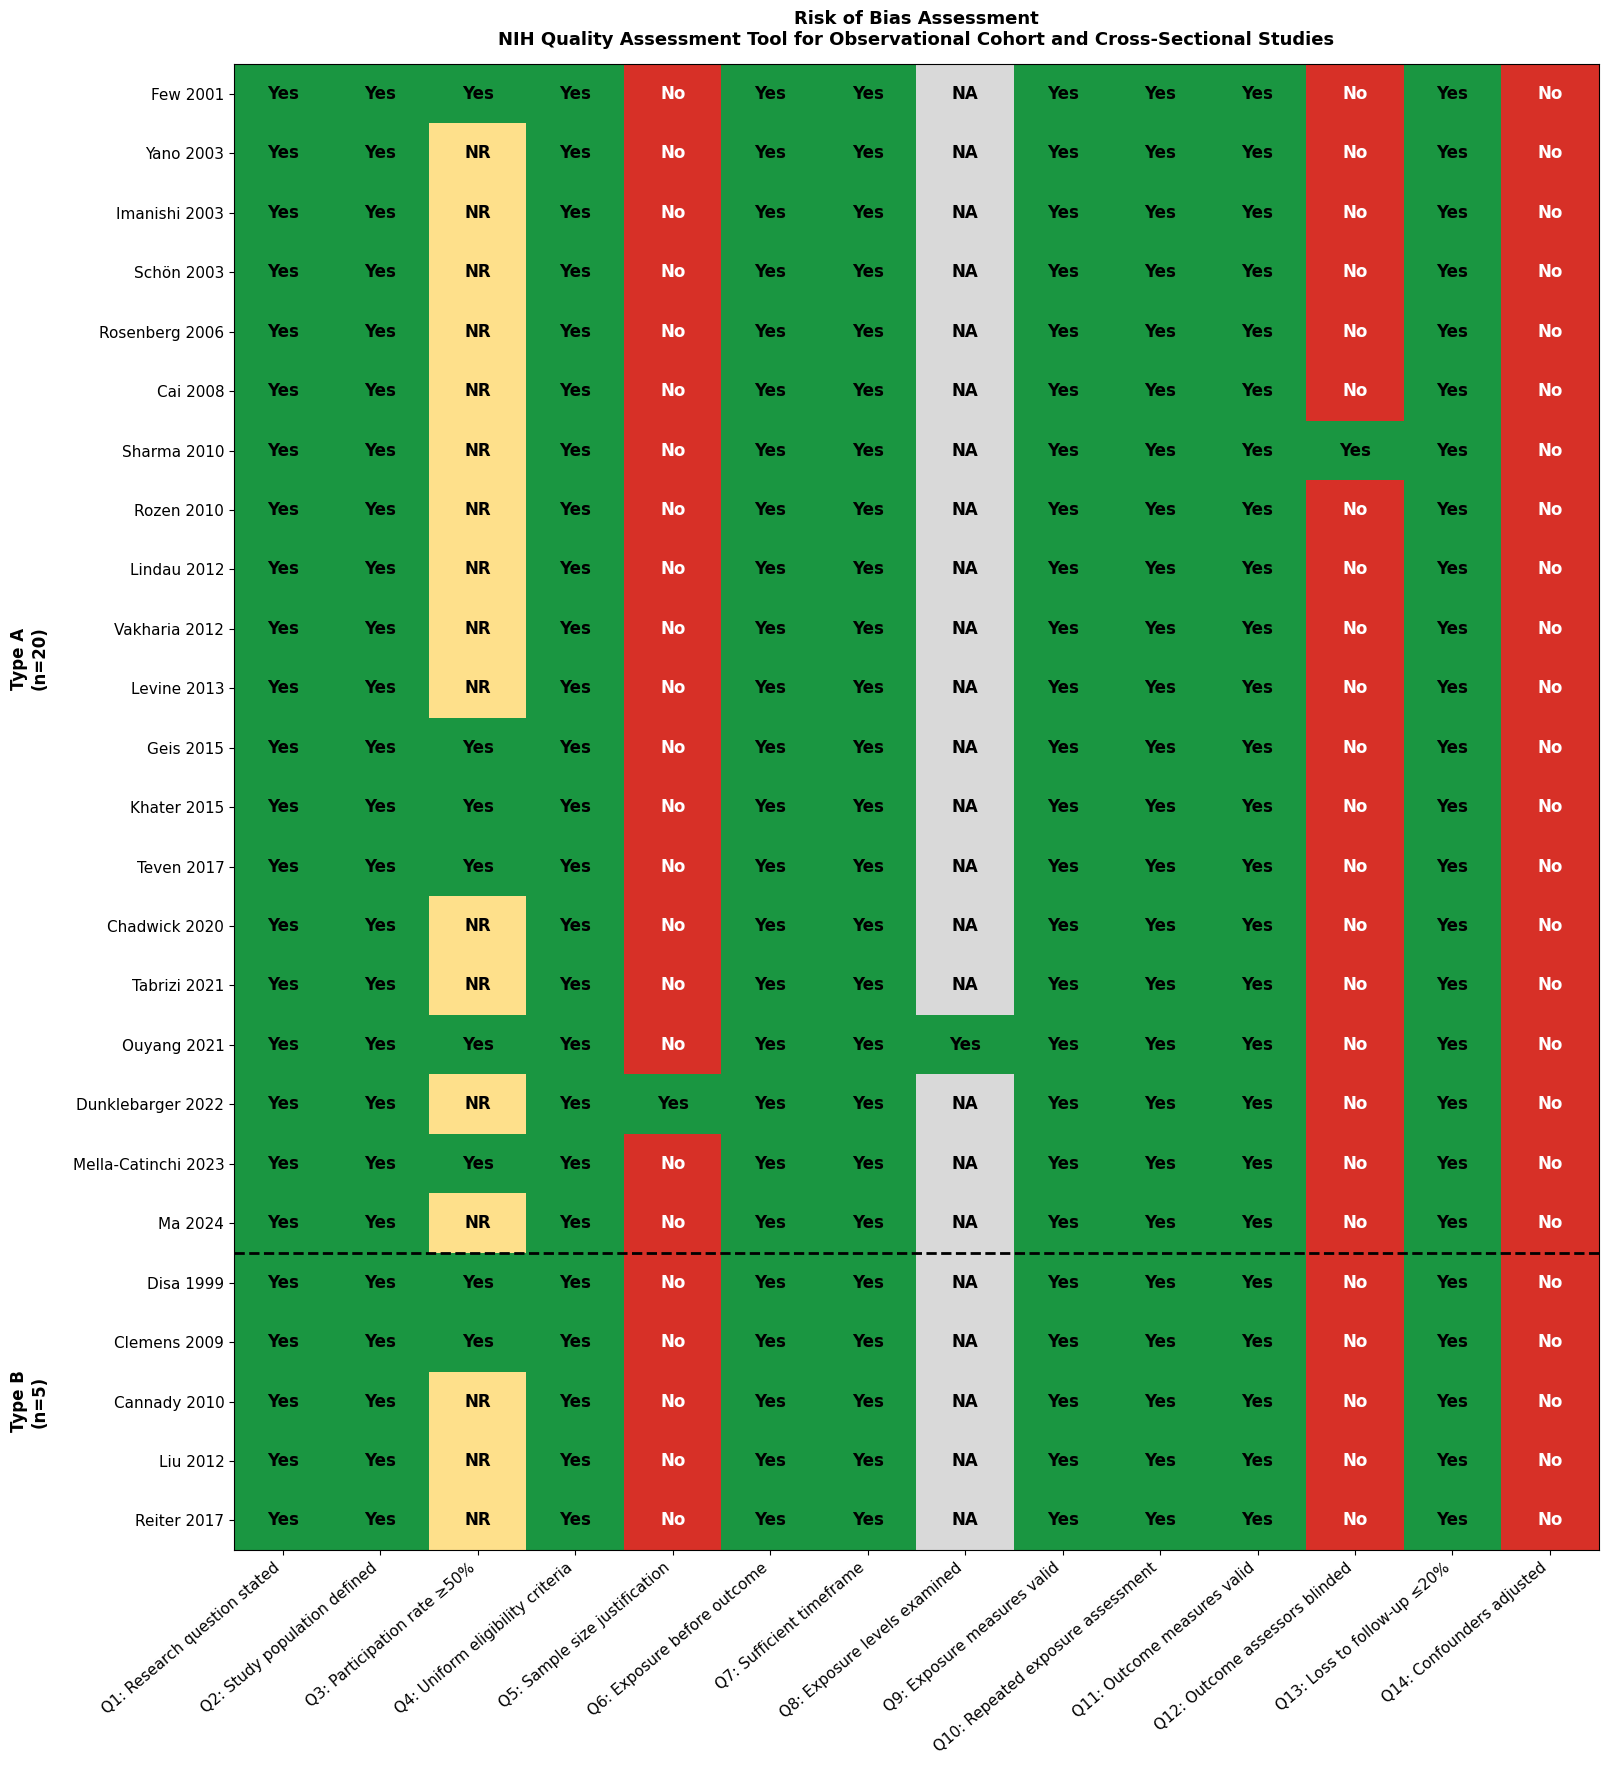

Saved: fig9_quality_heatmap.png / .pdf

=== Summary: Yes rate per question (Type A, n=20) ===
  Q1: Yes=20, No=0, NR=0, NA=0  → Yes rate (excl.NA)=100%
  Q2: Yes=20, No=0, NR=0, NA=0  → Yes rate (excl.NA)=100%
  Q3: Yes=6, No=0, NR=14, NA=0  → Yes rate (excl.NA)=30%
  Q4: Yes=20, No=0, NR=0, NA=0  → Yes rate (excl.NA)=100%
  Q5: Yes=1, No=19, NR=0, NA=0  → Yes rate (excl.NA)=5%
  Q6: Yes=20, No=0, NR=0, NA=0  → Yes rate (excl.NA)=100%
  Q7: Yes=20, No=0, NR=0, NA=0  → Yes rate (excl.NA)=100%
  Q8: Yes=1, No=0, NR=0, NA=0  → Yes rate (excl.NA)=100%
  Q9: Yes=20, No=0, NR=0, NA=0  → Yes rate (excl.NA)=100%
  Q10: Yes=20, No=0, NR=0, NA=0  → Yes rate (excl.NA)=100%
  Q11: Yes=20, No=0, NR=0, NA=0  → Yes rate (excl.NA)=100%
  Q12: Yes=1, No=19, NR=0, NA=0  → Yes rate (excl.NA)=5%
  Q13: Yes=20, No=0, NR=0, NA=0  → Yes rate (excl.NA)=100%
  Q14: Yes=0, No=20, NR=0, NA=0  → Yes rate (excl.NA)=0%

=== Summary: Yes rate per question (Type B, n=5) ===
  Q1: Yes=5, No=0, NR=0, NA=0  → Yes rate (

In [57]:
"""
Quality Assessment Heat Map
NIH Quality Assessment Tool for Observational Cohort and Cross-Sectional Studies
Type A (k=20) and Type B (k=5)
"""

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# ── データ読み込み ──────────────────────────────────────────
df = pd.read_csv("Quality Assessment Tool.csv")

df['label'] = df['author'] + ' ' + df['year'].astype(str)

q_cols = [f'Q{i}' for i in range(1, 15)]

q_labels = [
    'Q1: Research question stated',
    'Q2: Study population defined',
    'Q3: Participation rate ≥50%',
    'Q4: Uniform eligibility criteria',
    'Q5: Sample size justification',
    'Q6: Exposure before outcome',
    'Q7: Sufficient timeframe',
    'Q8: Exposure levels examined',
    'Q9: Exposure measures valid',
    'Q10: Repeated exposure assessment',
    'Q11: Outcome measures valid',
    'Q12: Outcome assessors blinded',
    'Q13: Loss to follow-up ≤20%',
    'Q14: Confounders adjusted',
]

# ── 数値マッピング ──────────────────────────────────────────
val_map = {'Yes': 1, 'No': 0, 'NR': 2, 'NA': 3}

df_A = df[df['Type'] == 'A'].sort_values('year').reset_index(drop=True)
df_B = df[df['Type'] == 'B'].sort_values('year').reset_index(drop=True)
df_sorted = pd.concat([df_A, df_B], ignore_index=True)

labels = df_sorted['label'].tolist()
mat = df_sorted[q_cols].map(lambda x: val_map.get(str(x).strip(), 3)).values

# ── カラーマップ ──────────────────────────────────────────
colors = ['#d73027', '#1a9641', '#fee08b', '#d9d9d9']
cmap = ListedColormap(colors)

# ── プロット ──────────────────────────────────────────────
n_studies = len(labels)
n_q = 14

fig_h = max(10, n_studies * 0.55 + 4)
fig, ax = plt.subplots(figsize=(16, fig_h))

im = ax.imshow(mat, cmap=cmap, vmin=0, vmax=3, aspect='auto')

# 軸ラベル
ax.set_xticks(range(n_q))
ax.set_xticklabels(q_labels, rotation=40, ha='right', fontsize=11)
ax.set_yticks(range(n_studies))
ax.set_yticklabels(labels, fontsize=11)

# セル内テキスト
for i in range(n_studies):
    for j in range(n_q):
        raw = df_sorted[q_cols[j]].iloc[i]
        val_str = str(raw).strip() if str(raw).strip() not in ['nan', 'NaN', ''] else 'NA'
        color = 'white' if val_str == 'No' else 'black'
        ax.text(j, i, val_str, ha='center', va='center', fontsize=12,
                color=color, fontweight='bold')

# Type A / B 区切り線
n_A = len(df_A)
ax.axhline(n_A - 0.5, color='black', linewidth=2.0, linestyle='--')

# Type ラベル
ax.text(-0.15, (n_A - 1) / 2, 'Type A\n(n=20)', ha='center', va='center',
        fontsize=12, fontweight='bold', rotation=90,
        transform=ax.get_yaxis_transform())
ax.text(-0.15, n_A + (len(df_B) - 1) / 2, 'Type B\n(n=5)', ha='center', va='center',
        fontsize=12, fontweight='bold', rotation=90,
        transform=ax.get_yaxis_transform())

ax.set_title(
    'Risk of Bias Assessment\n'
    'NIH Quality Assessment Tool for Observational Cohort and Cross-Sectional Studies',
    fontsize=13, fontweight='bold', pad=14
)

plt.tight_layout()
plt.savefig('fig9_quality_heatmap.png', dpi=600, bbox_inches='tight')
plt.savefig('fig9_quality_heatmap.pdf', bbox_inches='tight')
plt.show()
print("Saved: fig9_quality_heatmap.png / .pdf")

# ── 要約統計 ──────────────────────────────────────────────
print("\n=== Summary: Yes rate per question (Type A, n=20) ===")
for j, q in enumerate(q_cols):
    vals = df_A[q].tolist()
    yes = vals.count('Yes')
    no  = vals.count('No')
    nr  = vals.count('NR')
    na  = vals.count('NA')
    denom = yes + no + nr
    pct = yes / denom * 100 if denom > 0 else float('nan')
    print(f"  {q}: Yes={yes}, No={no}, NR={nr}, NA={na}  → Yes rate (excl.NA)={pct:.0f}%")

print("\n=== Summary: Yes rate per question (Type B, n=5) ===")
for j, q in enumerate(q_cols):
    vals = df_B[q].tolist()
    yes = vals.count('Yes')
    no  = vals.count('No')
    nr  = vals.count('NR')
    na  = vals.count('NA')
    denom = yes + no + nr
    pct = yes / denom * 100 if denom > 0 else float('nan')
    print(f"  {q}: Yes={yes}, No={no}, NR={nr}, NA={na}  → Yes rate (excl.NA)={pct:.0f}%")